#### Summary: 
Here I'll revisit the HiChIP overlap enrichment comparisons between links methods. It's been over a year since I first worked on this and now I want to redo everything in a clean notebook and double check all my methods for mistakes. Additionally, now that we're using all links methods, we may be able to include these overlaps in the paper, even though they don't show SMORES as the best method. These analyses are done on sets of links binned by distances, as well as sets of significant links found by multiple methods. 

- Significant sets: all links within distance bins, subsampled down to match size of background set if larger
- Background sets: all links within same distance bins, subsampled down to match size of significant set if larger
- After everything removes thresholded files to save space

# 1. Basic Preparation

In [1]:
# Import necessary libraries
suppressMessages(library(tidyverse))
suppressMessages(library(stringr))
suppressMessages(library(data.table))
suppressMessages(library(grid))

suppressMessages(library(tictoc))
suppressMessages(library(UpSetR))
suppressMessages(library(cicero))
suppressMessages(library(pheatmap))
suppressMessages(library(RColorBrewer))

suppressMessages(library(parallel))

In [2]:
# Define celltypes list
celltypes <- c('beta','alpha','delta','gamma','acinar','ductal')

# Define colors for each celltype (same order as celltypes)
colors <- c('#3F98E0', '#F51646', '#E39E14', '#A1D99B', '#F5DE6C', '#09850B')

In [3]:
# Define names and colors for link methods
link_methods <- c('sm', 'sl', 'abc', 'cic')
link_colors <- c('#B35D91', '#56B05C', '#4568A8', '#D8C45E')
names(link_colors) <- link_methods

# Define overlap sets and colors
overlap_colors <- c('sm_sl_abc_cic'='#000000',
                    'sl_abc_cic'='#6E9183','sm_sl_cic'='#A58C77','sm_sl_abc'='#81758A','sm_abc_cic'='#867D90',
                    'sl_cic'='#97BA5D','sl_abc'='#4E8C82','abc_cic'='#8F9683','sm_sl'='#858777','sm_cic'='#C69178','sm_abc'='#7C639D',
                    'sl'='#56B05C','cic'='#D8C45E','abc'='#4568A8','sm'='#B35D91')
link_sets <- names(overlap_colors)

In [4]:
distance_bins <- c('100000-250000', '50000-100000', '10000-50000', '0-10000')

In [5]:
# disable scientific notation for the filepath names of larger distances
options(scipen = 999)
set.seed(8)

### Important file paths

In [6]:
links_dir <- "/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/cRE-gene_links/links"

In [7]:
overlap_prefix <- file.path(links_dir,'combined/')
overlap_suffix1 <- '_all_methods_sig_links.bedpe'
overlap_suffix2 <- '_all_methods_bg_links.bedpe'

In [8]:
# HiChIP files
#made versions of these files without the headers
hichip_dir    <-'/nfs/lab/hmummey/multiomic_islet/intermediates/221017_recluster_final_cRE-gene_links/hichip'

endoc_fp      <- file.path(hichip_dir,'endoc_untreated_merged.loops.bedpe')
islet_high_fp <- file.path(hichip_dir,'Human_Islets_High_S11_L004.5k.1.sig3Dinteractions.bedpe')
islet_low_fp  <- file.path(hichip_dir, 'Human_Islets_Low_S12_L004.5k.1.sig3Dinteractions.bedpe')

hichip_fps <- c(endoc_fp, islet_high_fp, islet_low_fp)
prefixes   <- c('endob', 'islet_high_glucose', 'islet_low_glucose')
names(hichip_fps) <- prefixes

In [9]:
outdir <- '/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/cRE-gene_links/HiChIP_overlaps'

### Define necessary reference files

In [10]:
# read in the gene coords ref file
ref_df <- read.table('/nfs/lab/ABC/references/gene_coords.gencodev32.hg38.bed', sep='\t', header=FALSE) #read in gene coords ref

# 2. Calculate HiChIP overlap of links from different method overlap sets

### Functions

In [11]:
### Extra function to perform overlaps, so I can parallelize (also cuts links down randomly)
run_compare_connections <- function(N, links, num_links, hichip, max_bp=1000){
    # Randomly cut down links as necessary
    fin_links <- links[sample(dim(links)[1], num_links),]
    
    # Make links sets
    links <- data.frame(Peak1 = paste(fin_links$V1, fin_links$V2, fin_links$V3, sep="_"),
                    Peak2 = paste(fin_links$V4, fin_links$V5, fin_links$V6, sep="_"))
    hichip_links <- data.frame(Peak1 = paste(hichip[,1], hichip[,2], hichip[,3], sep="_"),
                               Peak2 = paste(hichip[,4], hichip[,5], hichip[,6], sep="_"))
    
    # Overlap using cicero compare_connections and return summary of overlaps
    inn = compare_connections(links, hichip_links, maxgap=max_bp)
    return(sum(inn))
}

In [12]:
### Use Cicero's compare_connections() function to find overlap between method links and HiChIP links
### This assumes none of the link files have headers
overlap_with_hichip <- function(method_set, sig_links, bg_links, hichip_fp, N=100, max_bp=1000){
    # Check if we have enough links before proceeding
    if (dim(sig_links)[1] < 10){
        print(paste('Not enough significant links found in link method set:', method_set))
        return(c(method_set,dim(sig_links)[1],NA,NA,NA))
    } else {
        # Read in hichip data
        hichip <- read.table(hichip_fp, sep='\t', header=FALSE)
        
        # Remove any significant links from the background (just in case weren't previously removed)
        sig_links$link <- paste(paste(sig_links$V1, sig_links$V2, sig_links$V3, sep="-"), sig_links$V7, sep='_')
        bg_links$link <- paste(paste(bg_links$V1, bg_links$V2, bg_links$V3, sep="-"), bg_links$V7, sep='_')
        bg_links_cut <- bg_links[!bg_links$link %in% sig_links$link,]

        # If more bg links than sig links, subsample and calculate overlap many times
        if (dim(bg_links_cut)[1] > dim(sig_links)[1]){
            bg_overlaps <- unlist(mclapply(seq(1,N), run_compare_connections, bg_links_cut, dim(sig_links)[1], hichip, mc.cores=10))
            bg_overlap <- round(mean(bg_overlaps))
            sig_overlap <- run_compare_connections(1, sig_links, dim(sig_links)[1], hichip)
            num_links <- dim(sig_links)[1]
        } else {
            print(paste('Less background links than significant!', method_set))
            bg_overlap <- run_compare_connections(1, bg_links_cut, dim(bg_links_cut)[1], hichip)
            sig_overlaps <- unlist(mclapply(seq(1,N), run_compare_connections, sig_links, dim(bg_links_cut)[1], hichip, mc.cores=10))
            sig_overlap <- round(mean(sig_overlaps))
            num_links <- dim(bg_links_cut)[1]
        }

        # Compile all the data for output
        outlist <- c(method_set, num_links, sig_overlap, num_links, bg_overlap)
        return(outlist)
    }
}

In [13]:
### Basic function to run Fisher's exact test for enrichment using an input data.table (2 x 2)
### Returns vector of (CI left side, odds ratio, CI right side, pvalue)
test_hichip_enrichment <- function(df_row){
    # Set up data table (2 x 2) for test
    data <- data.frame('links_match'=c(as.numeric(df_row[['signif_links_overlap_HiChIP']]), as.numeric(df_row[['nonsignif_links_overlap_HiChIP']])),
                        'total_links'=as.numeric(c(df_row[['signif_links']]), as.numeric(df_row[['nonsignif_links']])),
                        row.names=c('signif_links','nonsignif_links'))
    data_fin <- as.matrix(data)
    test <- fisher.test(data_fin)
    vector <- c(test$conf.int[1], test$estimate, test$conf.int[2], test$p.value)
    return(vector)
}


### Function to read in 3 method compare connections output files and run Fisher's exact test for enrichment
### for a given celltype, then create a Forest plot comparing the odds ratio and CIs
calculate_hichip_eqtl_enrichment <- function(df){
    # Run Fisher's exact test for each row in each df_fin that isn't NA
    non_na <- subset(df, !is.na(signif_links_overlap_HiChIP))
    tests <- apply(non_na, 1, test_hichip_enrichment)
    test_results <- as.data.frame(t(tests))
    colnames(test_results) <- c('CI_L','odds_ratio','CI_R','pval')
    test_results$method_set <- non_na$method_set
    return(test_results)    
}

In [14]:
### Overall enrichment wrapper
wrapper_hichip_enrichment_method_bins <- function(celltype, method_strs, hichip_fp, hichip_prefix, outdir){
    # First read in the combined links file paths (sig and bg)
    sig_fp <- paste0(overlap_prefix,celltype,overlap_suffix1)
    sig_links <- fread(sig_fp)
    bg_fp <- paste0(overlap_prefix,celltype,overlap_suffix2)
    bg_links <- fread(bg_fp)
    
    # Then test for HiChIP overlap for each method overlap set
    overlap_df <- data.frame()
    for (method_set in method_strs){
        sig_links_sub <- subset(sig_links, V9==method_set)
        results <- overlap_with_hichip(method_set, sig_links_sub, bg_links, hichip_fp)
        overlap_df <- rbind(overlap_df, results)
    }
    
    # A few modifications to the overlap dataframe and write out
    colnames(overlap_df) <- c('method_set','signif_links','signif_links_overlap_HiChIP','nonsignif_links','nonsignif_links_overlap_HiChIP')
    out_fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_%s_HiChIP_overlap.link_methods_sets.txt', celltype, hichip_prefix))
    write.table(overlap_df, out_fp, sep='\t', row.names = FALSE, col.names = TRUE, quote=FALSE)    
    
    # Now calculate enrichment with Fischer's test
    enrichment_res <- calculate_hichip_eqtl_enrichment(overlap_df)
    enrichment_res$num_links <- subset(overlap_df, !is.na(signif_links_overlap_HiChIP))$signif_links
    out_fp2 <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_%s_HiChIP_overlap.link_methods_sets.Fishers_enrichment.txt',celltype, hichip_prefix))
    write.table(enrichment_res, out_fp2, sep='\t', col.names=TRUE, row.names=FALSE, quote=FALSE)
}

### Calculate enrichment of HiChIP overlaps

In [ ]:
# run the celltype comparison function 
tic()
for (prefix in names(hichip_fps)){
    hichip_fp <- hichip_fps[[prefix]]
    for (celltype in celltypes){
        print(paste(celltype, Sys.time()))
        wrapper_hichip_enrichment_method_bins(celltype, link_sets, hichip_fp, prefix, outdir)
    }
}
toc()

[1] "beta 2024-12-06 16:06:51"


Warning message in .Seqinfo.mergexy(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrX
  - in 'y': chr1, chr7, chr8, chr10, chr11, chr15, chr17, chr20, chr21
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."
Warning message in .Seqinfo.mergexy(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrX
  - in 'y': chr1, chr7, chr8, chr10, chr11, chr15, chr17, chr20, chr21
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."
Warning message in .Seqinfo.mergexy(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrX
  - in 'y': chr13
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."
Warning message in .Seqinfo.mergexy(x, y):
"E

# 3. Calculate HiChIP overlap of links thresholded by distance

### Functions (reusing some from previous section, so make sure to rerun those blocks!)

In [ ]:
### Function to calculate link distances from a bedpe style dataframe row
calc_link_distance <- function(link_df_row){
    CRE_start <- as.integer(link_df_row[2])
    CRE_end <- as.integer(link_df_row[3])
    gene_start <- as.integer(link_df_row[5])
    CRE_center <- CRE_start + (CRE_end - CRE_start)/2
    distance <- as.integer(abs(CRE_center - gene_start))
    return(distance)
}


### Function to figure out which distance bin a distance fits in
classify_distance_bin <- function(distance, distance_bins){
    min_dists <- as.numeric(str_split_fixed(distance_bins, '-', 2)[,1])
    max_dists <- as.numeric(str_split_fixed(distance_bins, '-', 2)[,2])
    min_in_bins <- (distance > min_dists)
    max_in_bins <- (distance < max_dists)
    both_true <- (min_in_bins & max_in_bins)
    bin <- distance_bins[which(both_true==TRUE)]
    return(bin)
}

In [ ]:
### Overall enrichment wrapper
wrapper_hichip_enrichment_distance_bins <- function(celltype, methods, distance_bins, hichip_fp, hichip_prefix, outdir){
    # First read in the combined links file paths (sig and bg)
    sig_fp <- paste0(overlap_prefix,celltype,overlap_suffix1)
    sig_links <- fread(sig_fp)
    bg_fp <- paste0(overlap_prefix,celltype,overlap_suffix2)
    bg_links <- fread(bg_fp)

    # Next calculate the distance for each link and assign to a distance bin
    sig_links$distance <- unlist(apply(sig_links, 1, calc_link_distance))
    sig_links$dist_bin <- sapply(sig_links$distance, classify_distance_bin, distance_bins)
    bg_links$distance <- unlist(apply(bg_links, 1, calc_link_distance))
    bg_links$dist_bin <- sapply(bg_links$distance, classify_distance_bin, distance_bins)

    # Then test for HiChIP overlap for each method AND distance bin
    overlap_df <- data.frame()
    for (method in methods){
        for (dist in distance_bins){
            method_set <- paste(method, dist, sep='_')
            print(method_set)
            sig_links_sub <- subset(sig_links, grepl(method, V9) & dist_bin==dist)
            bg_links_sub <- subset(bg_links, dist_bin==dist)
            results <- overlap_with_hichip(method_set, sig_links_sub, bg_links_sub, hichip_fp)
            overlap_df <- rbind(overlap_df, results)
        }
    }
    
    # A few modifications to the overlap dataframe and write out
    colnames(overlap_df) <- c('method_set','signif_links','signif_links_overlap_HiChIP','nonsignif_links','nonsignif_links_overlap_HiChIP')
    out_fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_%s_HiChIP_overlap.link_distance_bins.txt', celltype, hichip_prefix))
    write.table(overlap_df, out_fp, sep='\t', row.names = FALSE, col.names = TRUE, quote=FALSE)    
    
    # Now calculate enrichment with Fischer's test
    enrichment_res <- calculate_hichip_eqtl_enrichment(overlap_df)
    enrichment_res$num_links <- subset(overlap_df, !is.na(signif_links_overlap_HiChIP))$signif_links
    out_fp2 <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_%s_HiChIP_overlap.link_distance_bins.Fishers_enrichment.txt',celltype, hichip_prefix))
    write.table(enrichment_res, out_fp2, sep='\t', col.names=TRUE, row.names=FALSE, quote=FALSE)
}

### Calculate enrichment of HiChIP overlaps in different distance bins

In [ ]:
# run the celltype comparison function 
methods <- c('sm','sl','abc','cic')
tic()
for (prefix in names(hichip_fps)){
    hichip_fp <- hichip_fps[[prefix]]
    for (celltype in celltypes){
        print(paste(celltype, Sys.time()))
        wrapper_hichip_enrichment_distance_bins(celltype, methods, distance_bins, hichip_fp, prefix, outdir)
    }
}
toc()

# 4. Plot results

### Functions

In [27]:
### dedicated plotting function
plot_enrichment_comp_fin <- function(fp, xmax, ordered_method_sets, colors, title){
    # Read in table of Fisher's exact test odd's ratios and CIs
    data <- read.table(fp, sep='\t', header = TRUE)
    row.names(data) <- data$method_set
    data_cut_sort <- data[order(data$method_set),]
    
    # Set any values outside of xmax to the limits (also record which values exceed the limits)
    past_xmax <- row.names(data_cut_sort[data_cut_sort$CI_R > xmax,])
    data_cut_sort[past_xmax, 'CI_R'] <- xmax
    or_past_xmax <- row.names(data_cut_sort[data_cut_sort$odds_ratio > xmax,])
    
    # Prepare input vectors for arrows 
    data_cut_sort$max_arrow_L <- NA 
    data_cut_sort[past_xmax, 'max_arrow_L'] <- data_cut_sort[past_xmax,'odds_ratio'] + 0.5
    data_cut_sort$max_arrow_R <- NA
    data_cut_sort[past_xmax, 'max_arrow_R'] <- xmax
    if (length(or_past_xmax) > 0){
        print(or_past_xmax)
        data_cut_sort[or_past_xmax, 'max_arrow_L'] <- NA
        data_cut_sort[or_past_xmax, 'max_arrow_R'] <- NA
    }
    
    # Prepare strings for y-labels (get rid of underscore in rownames)
    y_labels <- rev(gsub('_', ' ', data_cut_sort$method_set))
        
    # Make a forest plot with the subsetted data
    #print(data_cut_sort)
    options(repr.plot.width = 12, repr.plot.height = 8)
    theme_set(
        theme_classic())

    p1 <- ggplot(data=data_cut_sort, aes(x=odds_ratio, y=method_set, group=celltype)) + 
            geom_vline(xintercept=seq(0, xmax, 1), linetype='dashed', color='black', alpha=0.5, size=0.5) + 
            geom_linerange(aes(xmin=CI_L, xmax=CI_R), size=0.75) + 
            geom_point(aes(x=odds_ratio), size=10, color=colors[data_cut_sort$method_set]) + 
            scale_color_manual() + xlim(0,xmax) + 
            # scale_y_discrete(labels=y_labels) + 
            xlab('Enrichment Odds Ratio (OR)') + ylab('Link set') + labs(title=title) + 
            theme(plot.title=element_text(size=20, hjust=0.5),
                  axis.text.x=element_text(size=20, vjust=0.5),
                  axis.text.y=element_text(size=20, vjust=0.5),
                  axis.title.x = element_text(size=20, vjust=-0.35),
                  axis.title.y = element_text(size=20, vjust=0.5),
                  legend.position = "none")
    if(length(past_xmax) > 0){
        p1 <- p1 + geom_segment(aes(x=max_arrow_L, xend=max_arrow_R, y=row.names(data_cut_sort), yend=row.names(data_cut_sort)),
                                lineend = 'butt', linejoin='mitre', size = 0.75, 
                                 arrow = arrow(length = unit(0.03, "npc")))
    }
    p1$data$method_set <- factor(x = p1$data$method_set, levels=rev(ordered_method_sets))
    print(p1)
}

### Make plots for link overlap sets results

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."


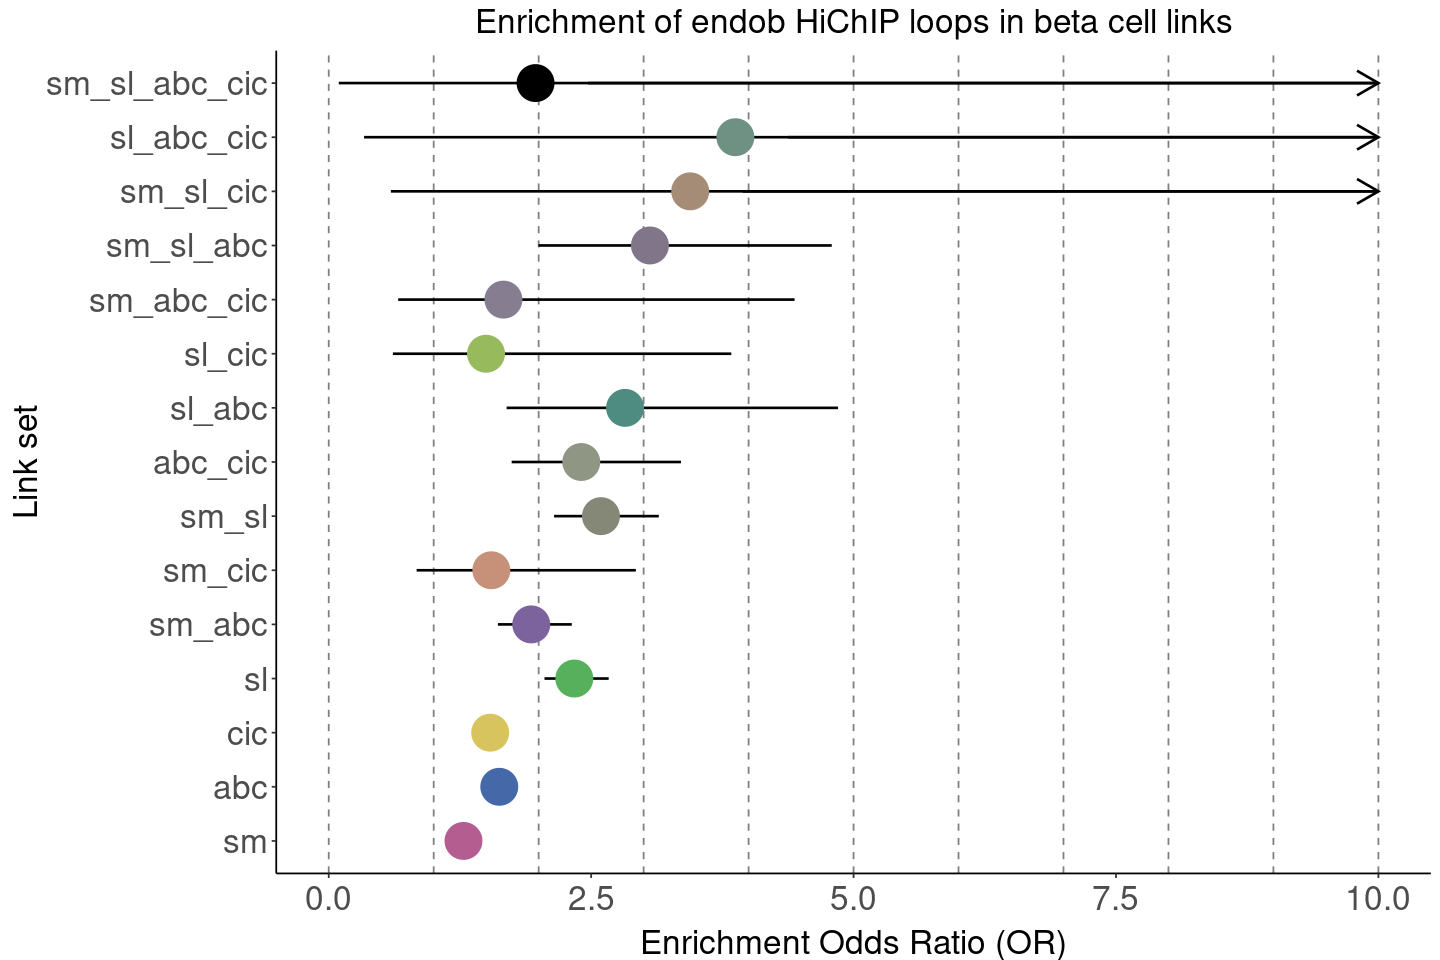

Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


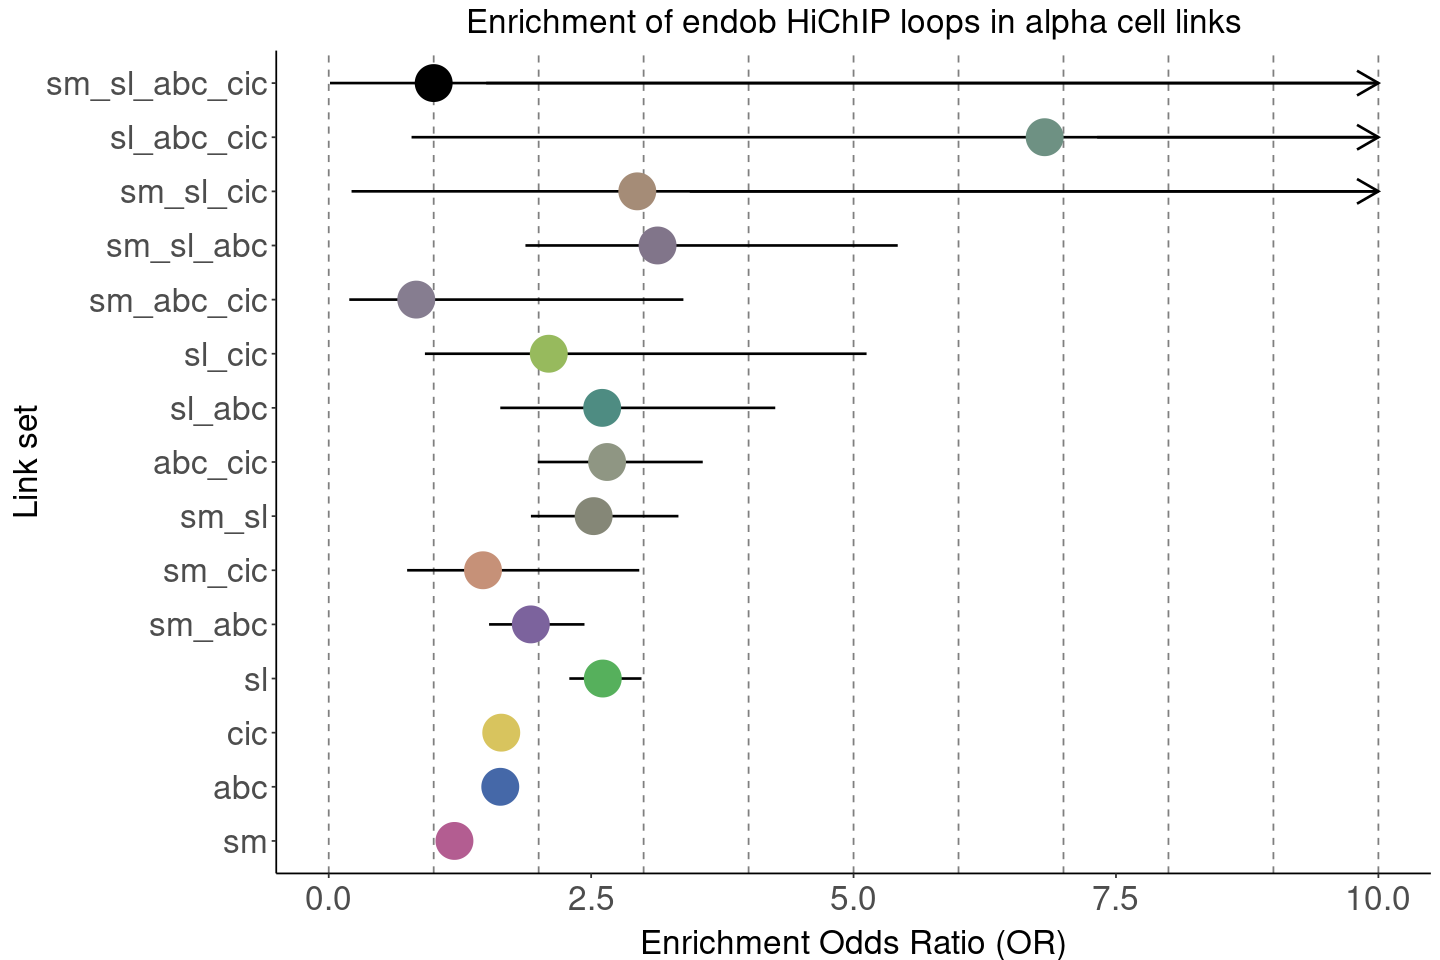

Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


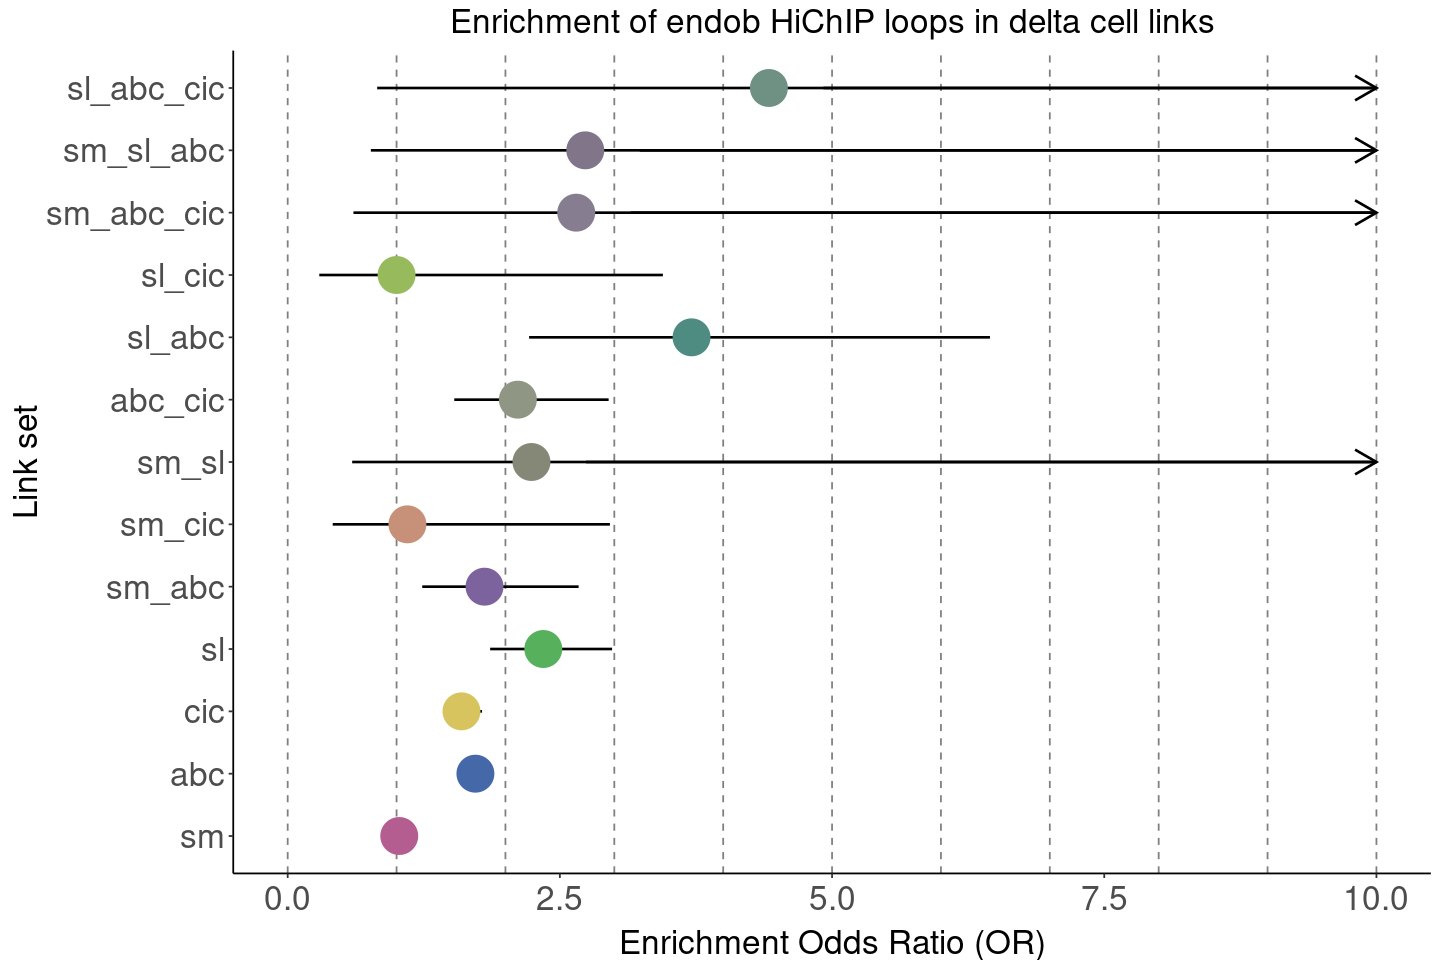

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."


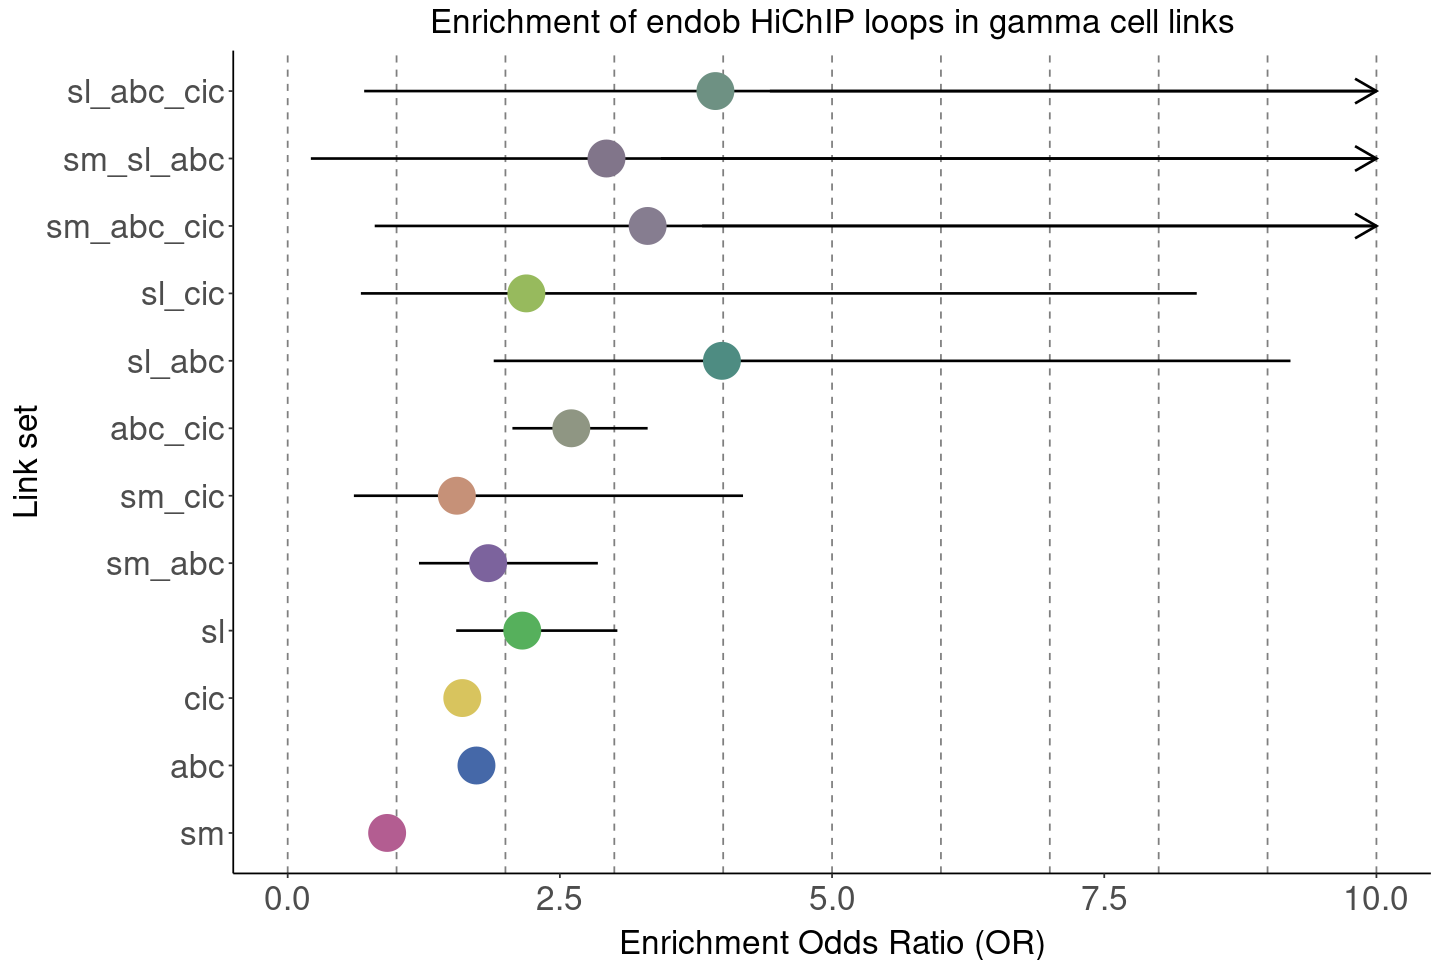

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."


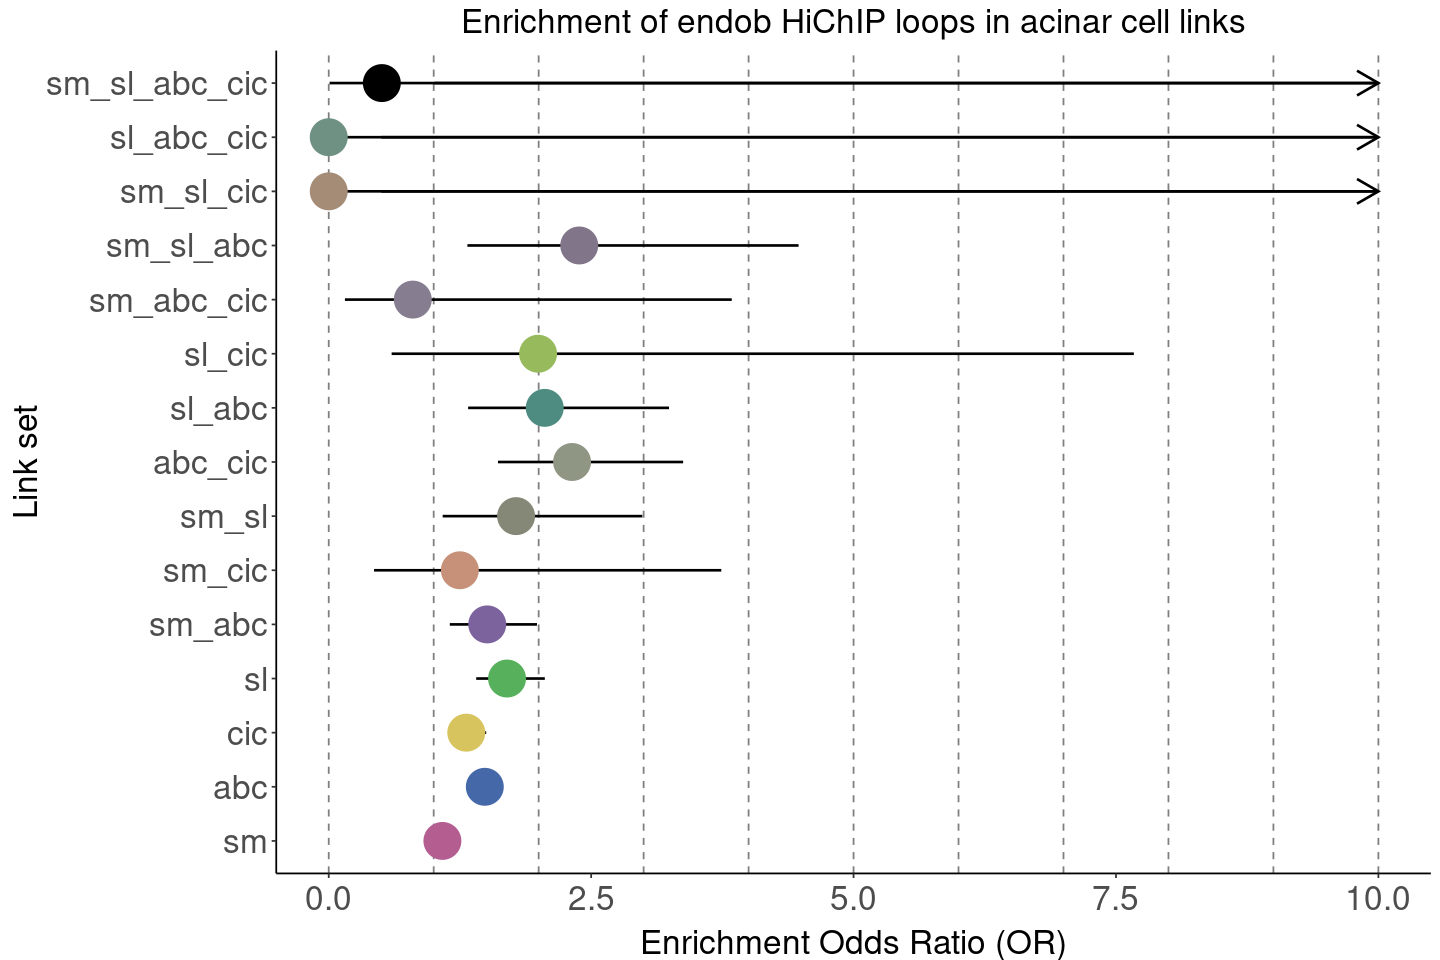

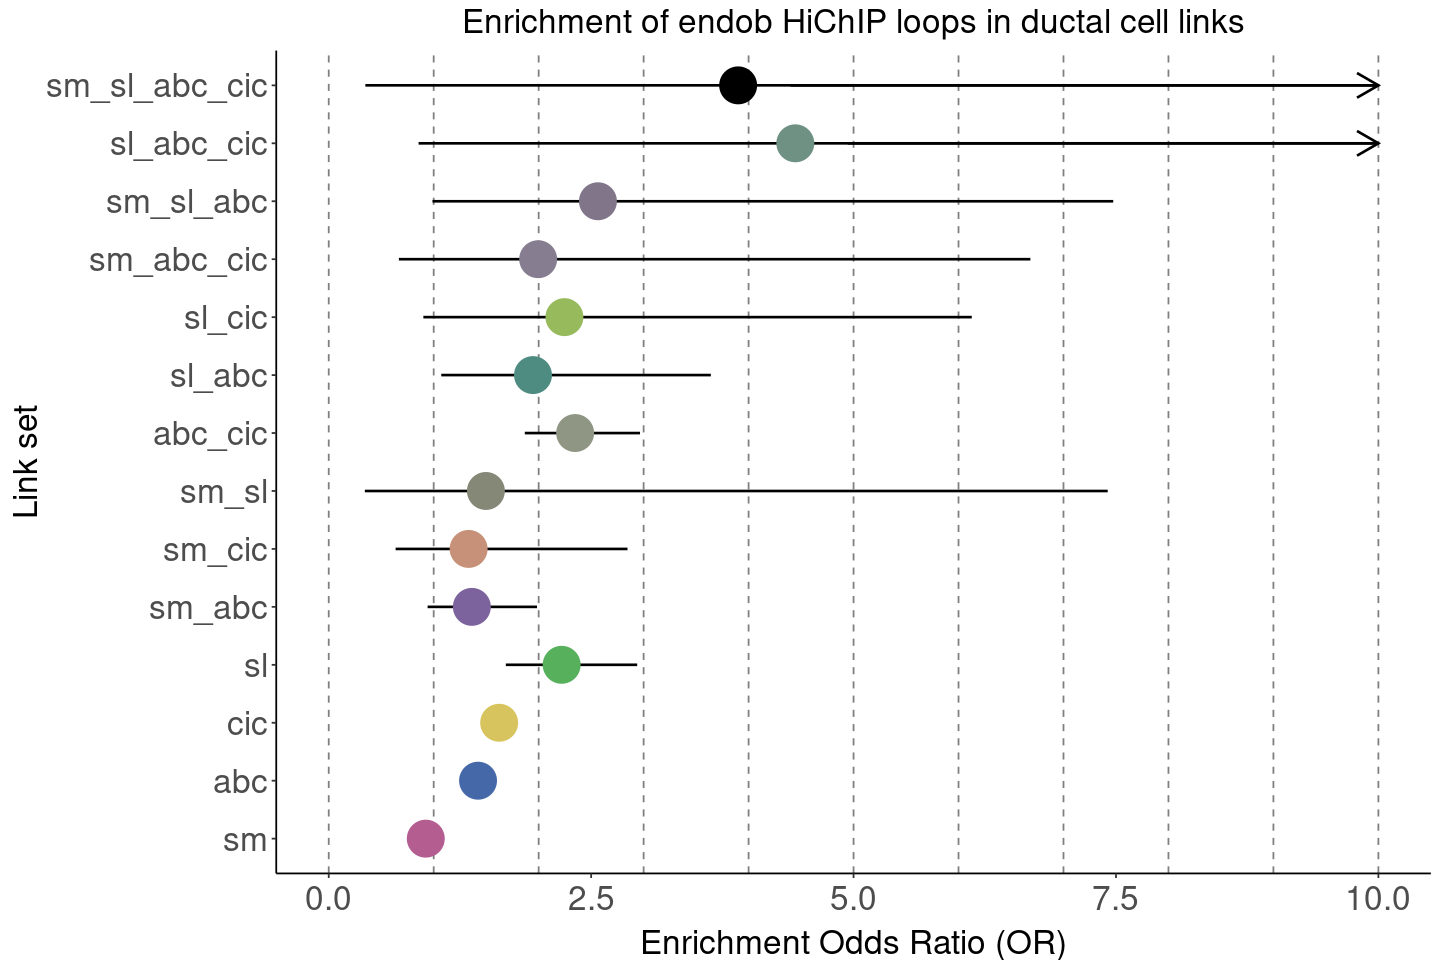

In [28]:
prefix <- prefixes[1]
for(celltype in celltypes){
    fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_%s_HiChIP_overlap.link_methods_sets.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 10, link_sets, overlap_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links',prefix, celltype))
}

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."


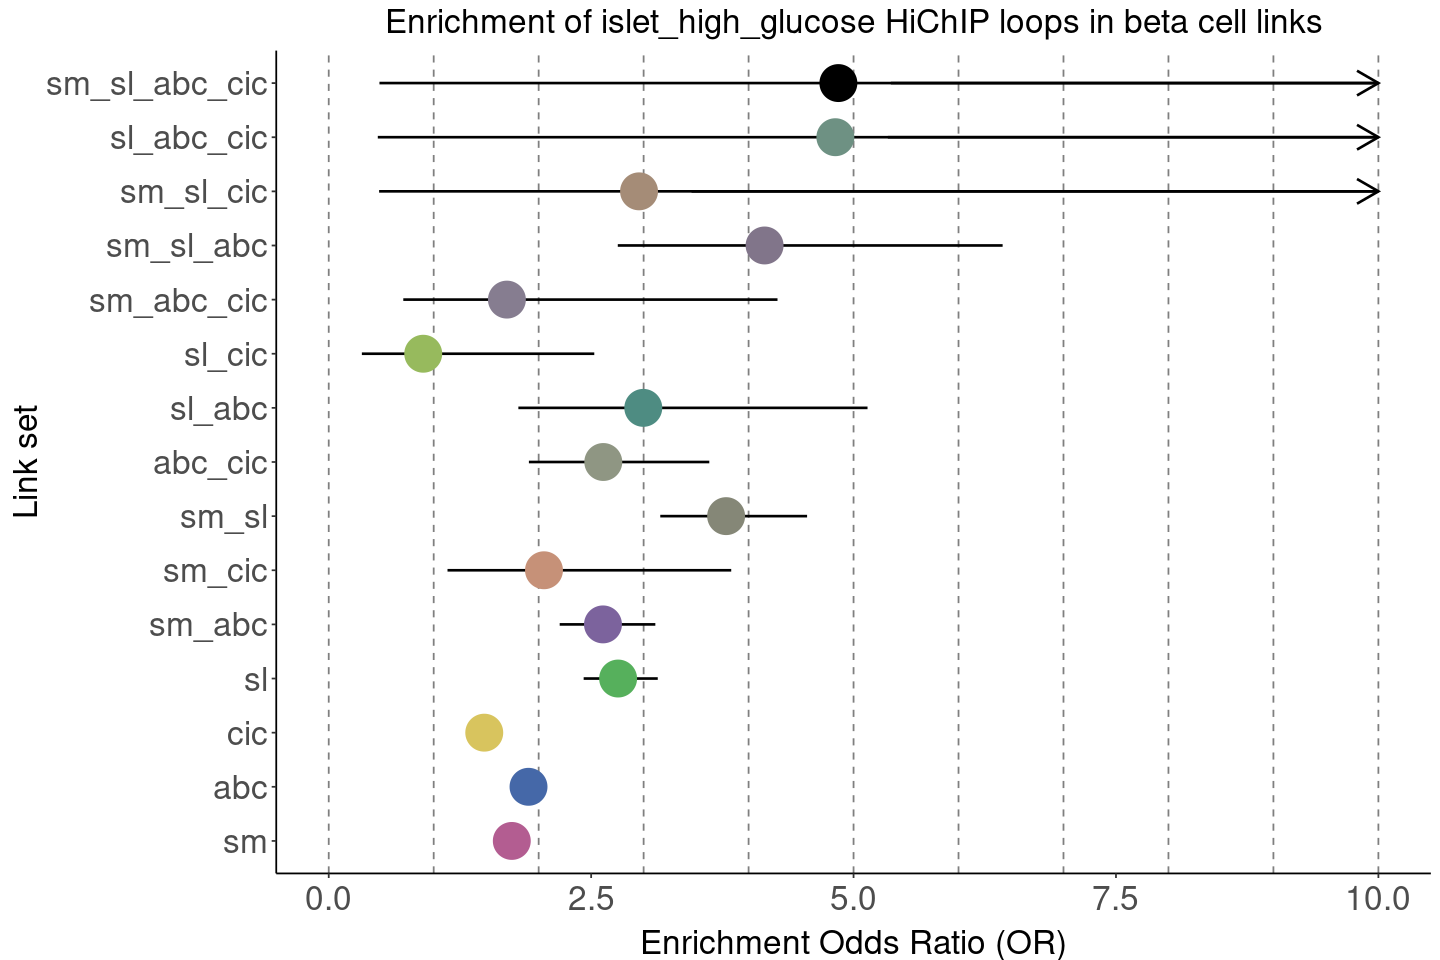

Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


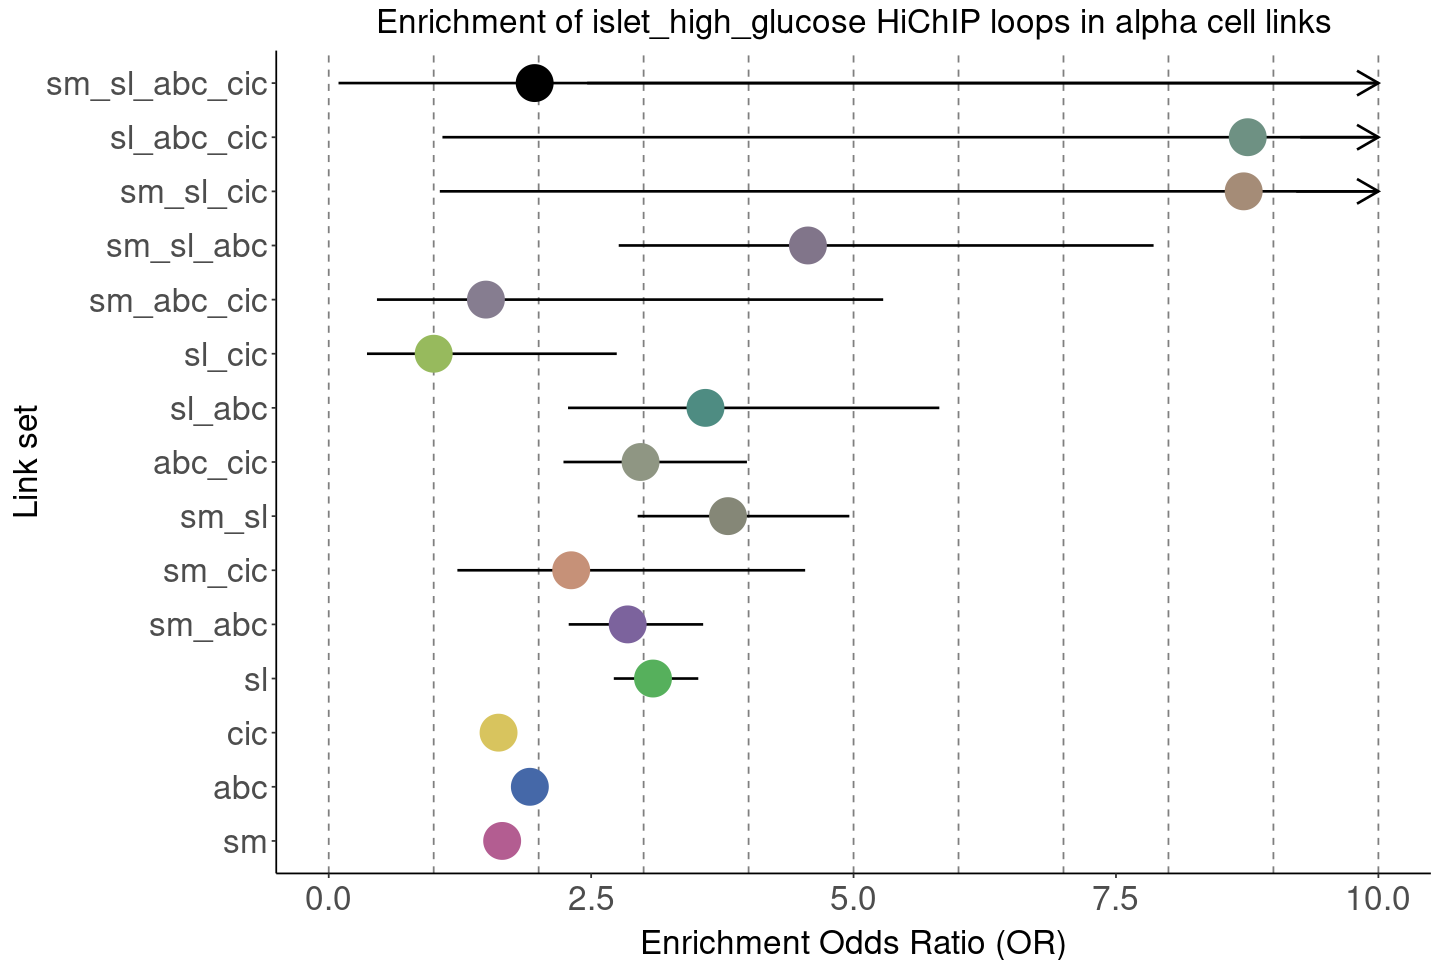

[1] "sl_abc_cic"


Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."
Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


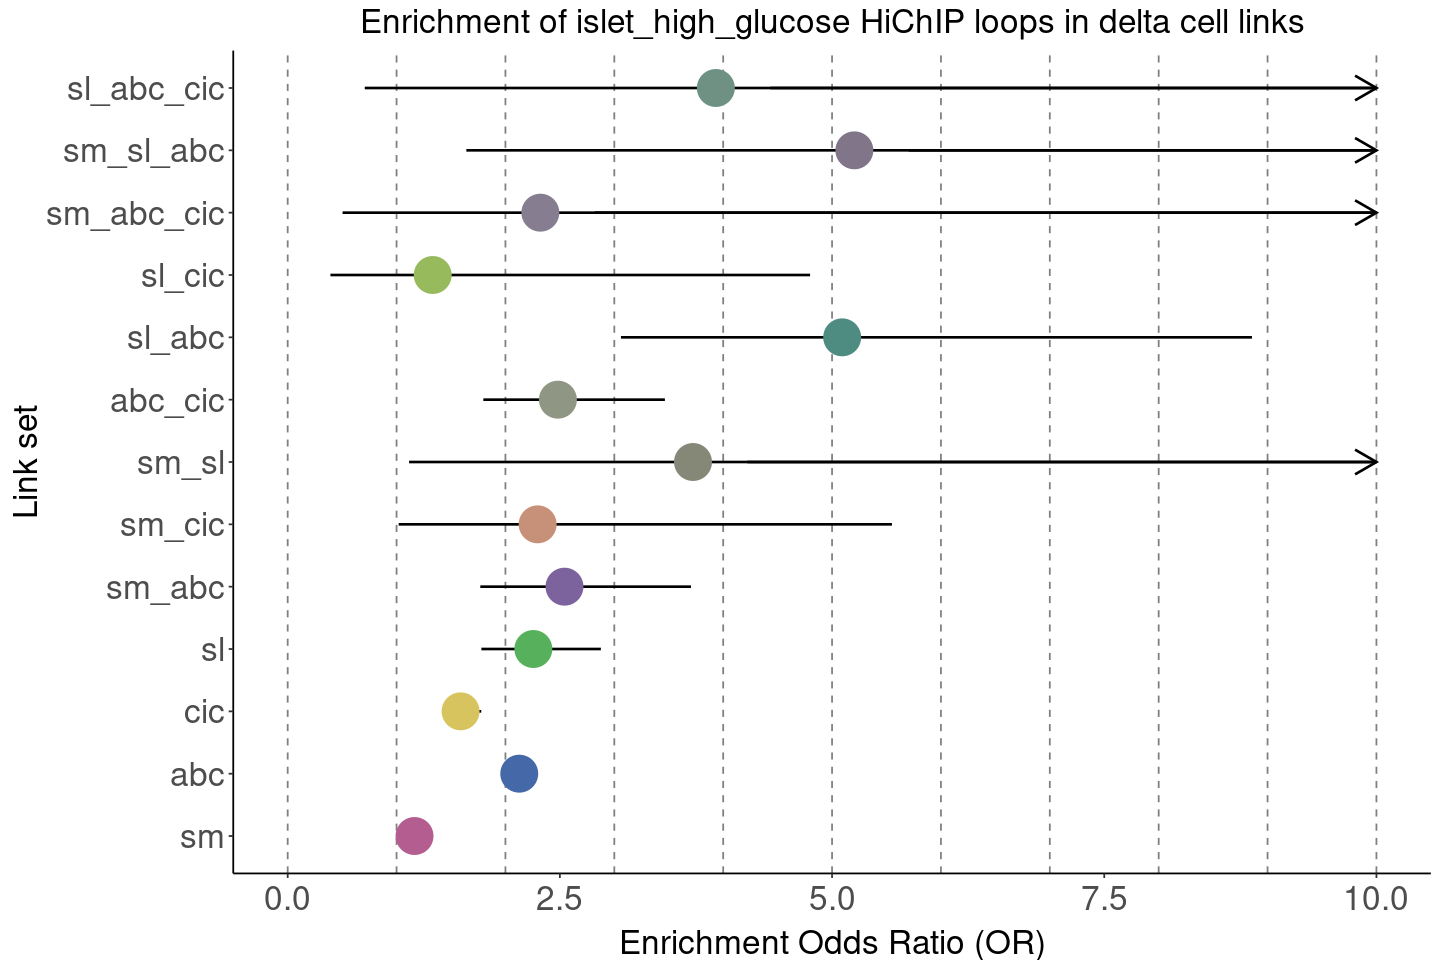

Warning message:
"Removed 11 rows containing missing values (`geom_segment()`)."


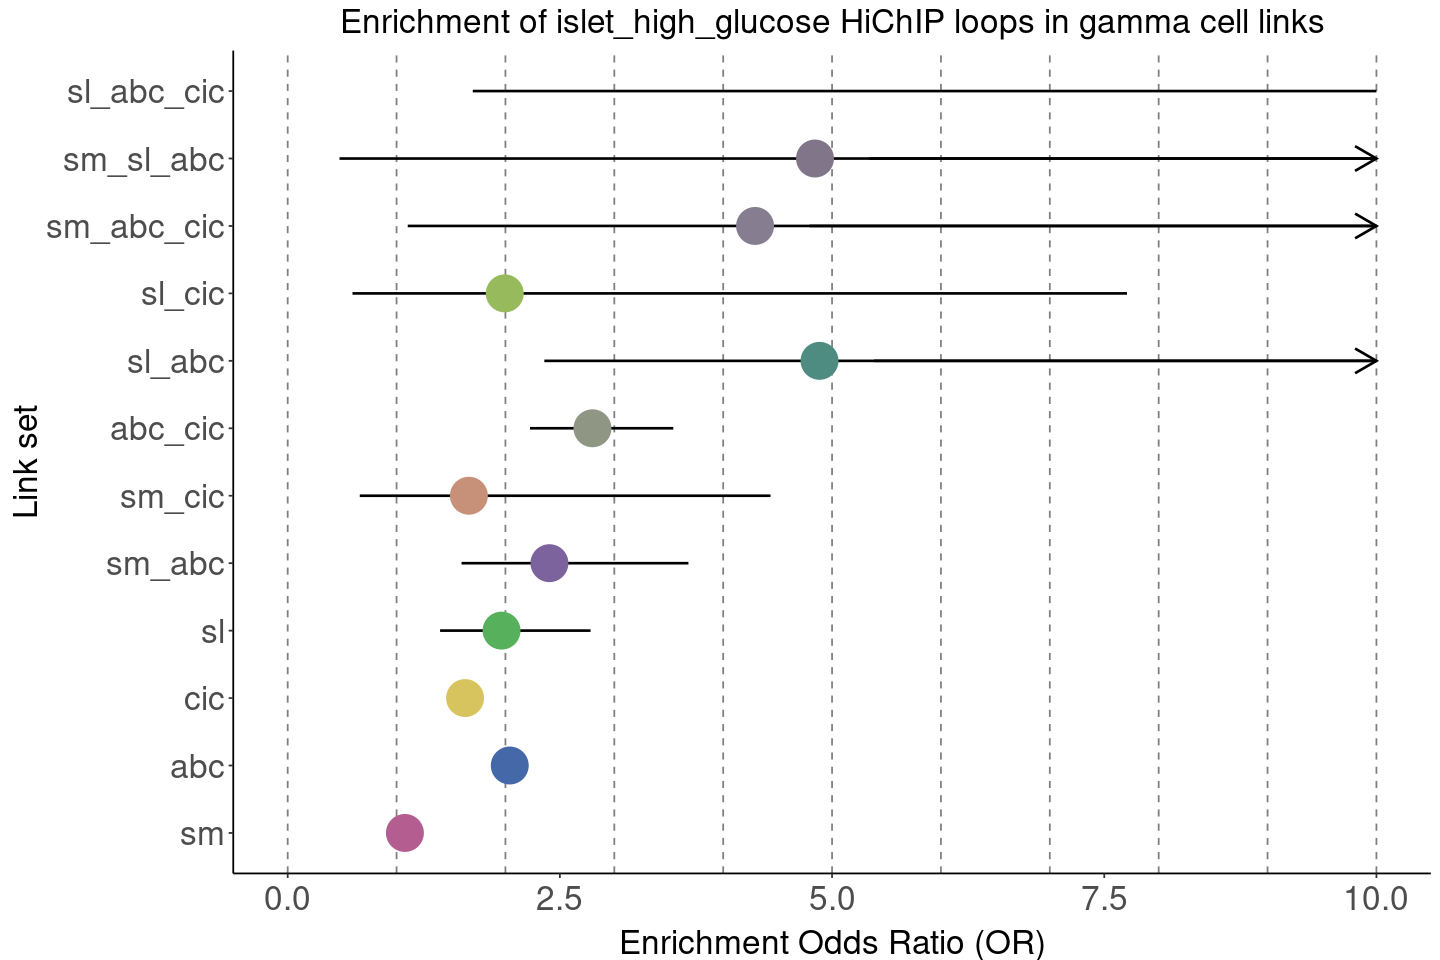

Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


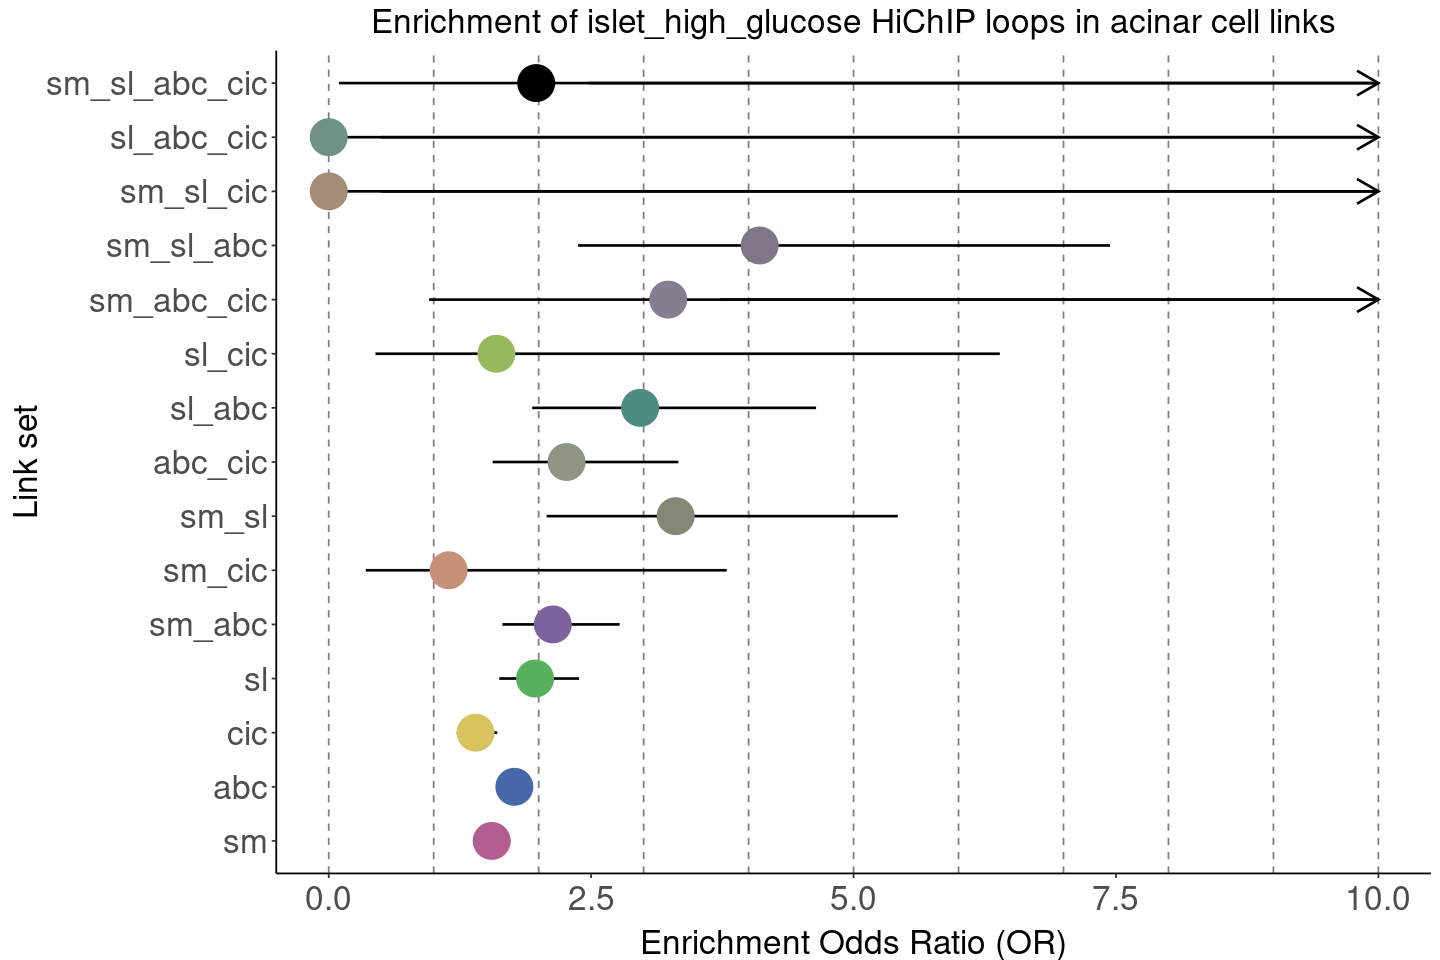

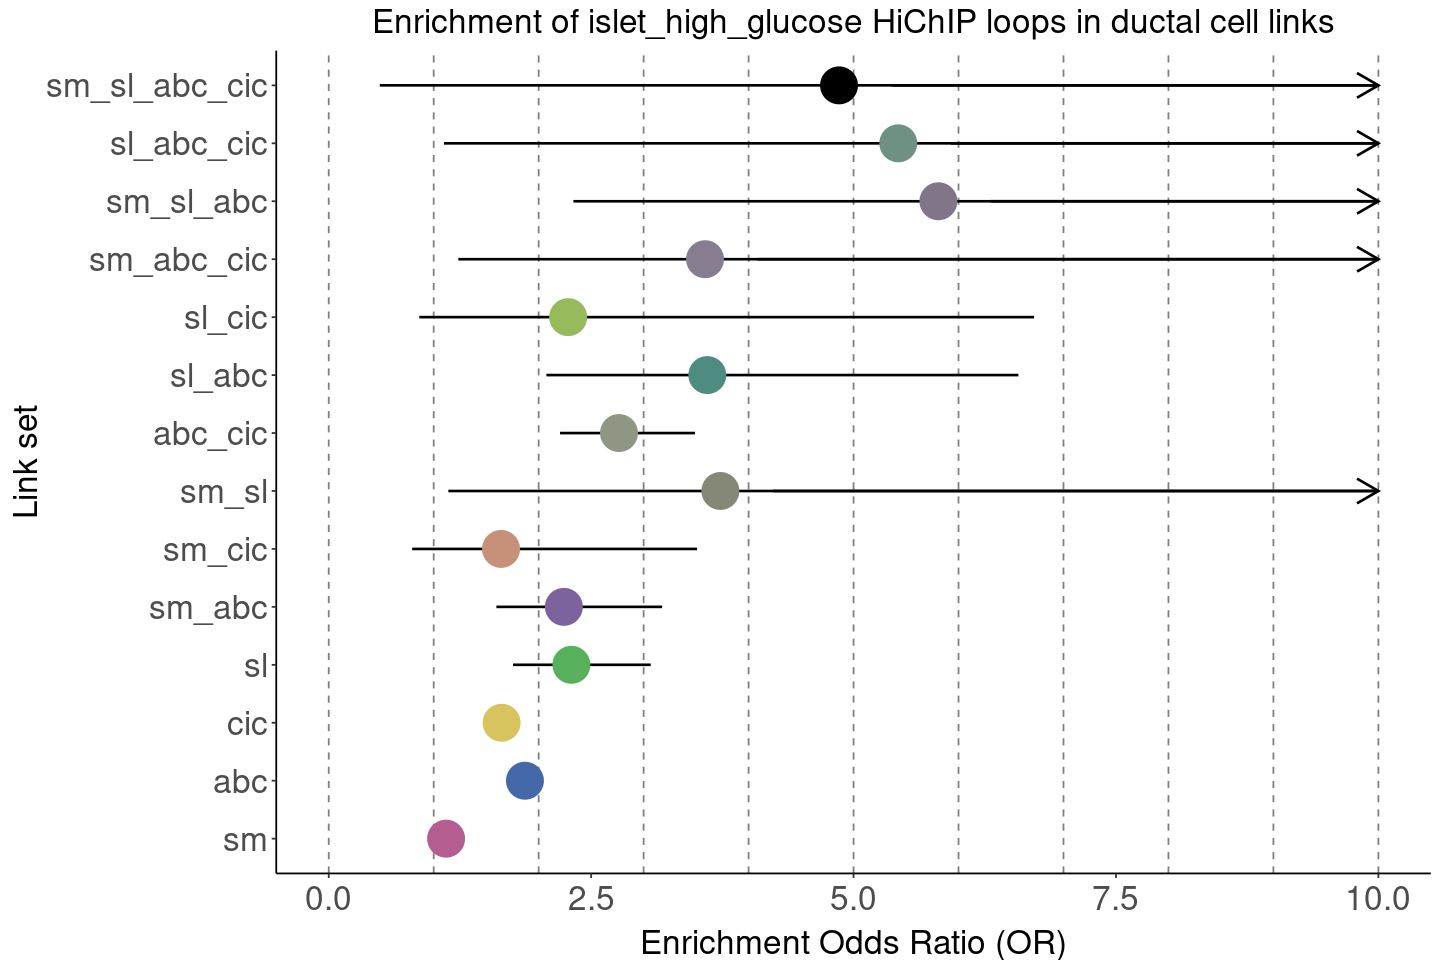

In [29]:
prefix <- prefixes[2]
for(celltype in celltypes){
    fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_%s_HiChIP_overlap.link_methods_sets.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 10, link_sets, overlap_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links',prefix, celltype))
}

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


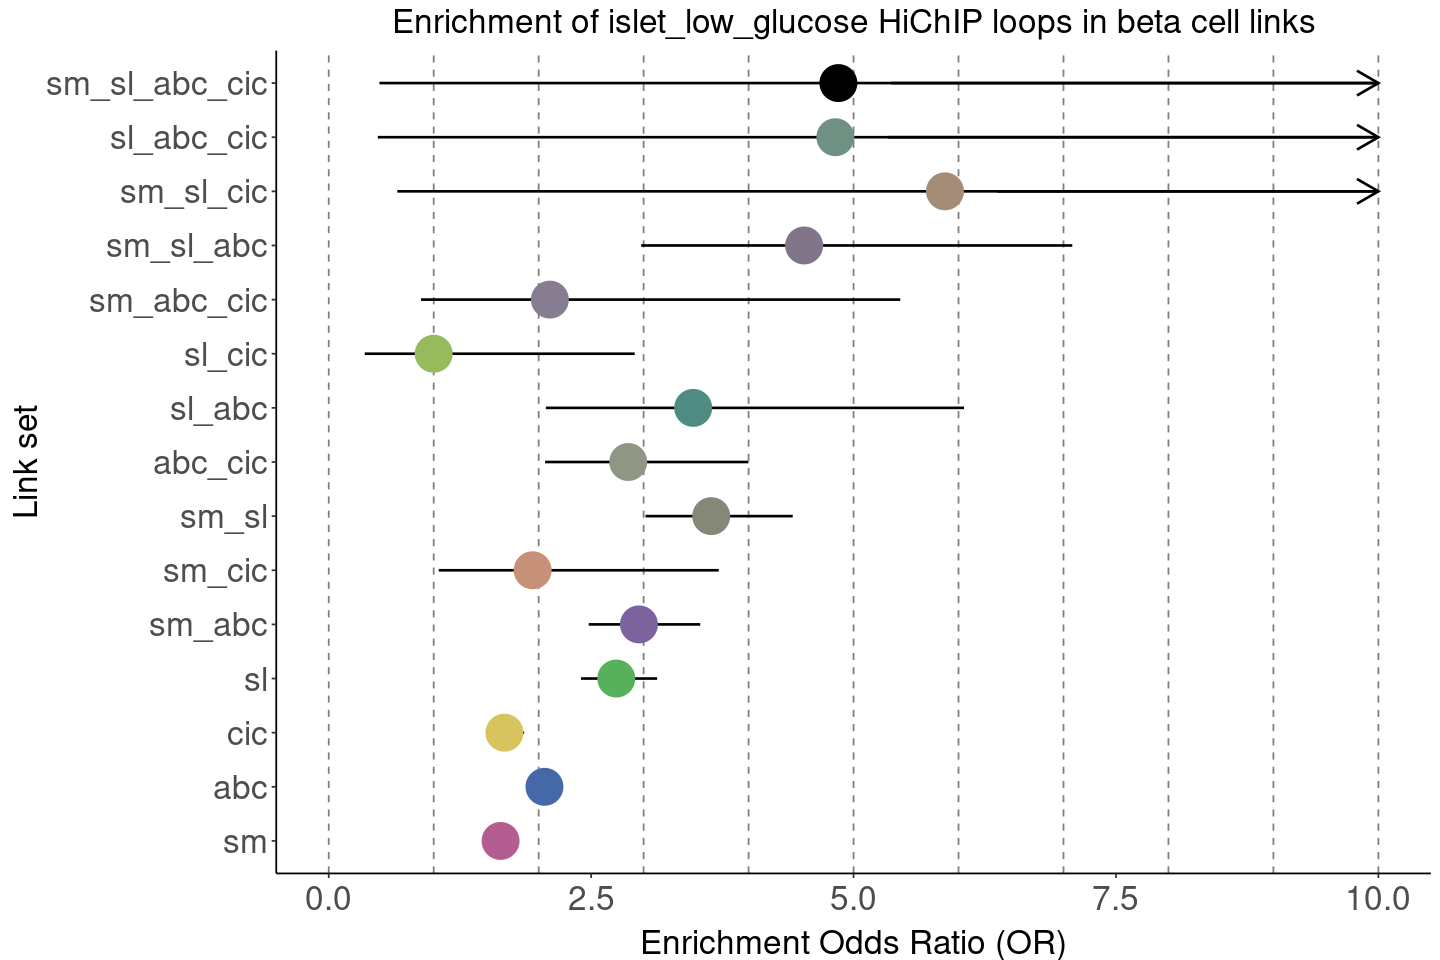

Warning message:
"Removed 8 rows containing missing values (`geom_segment()`)."


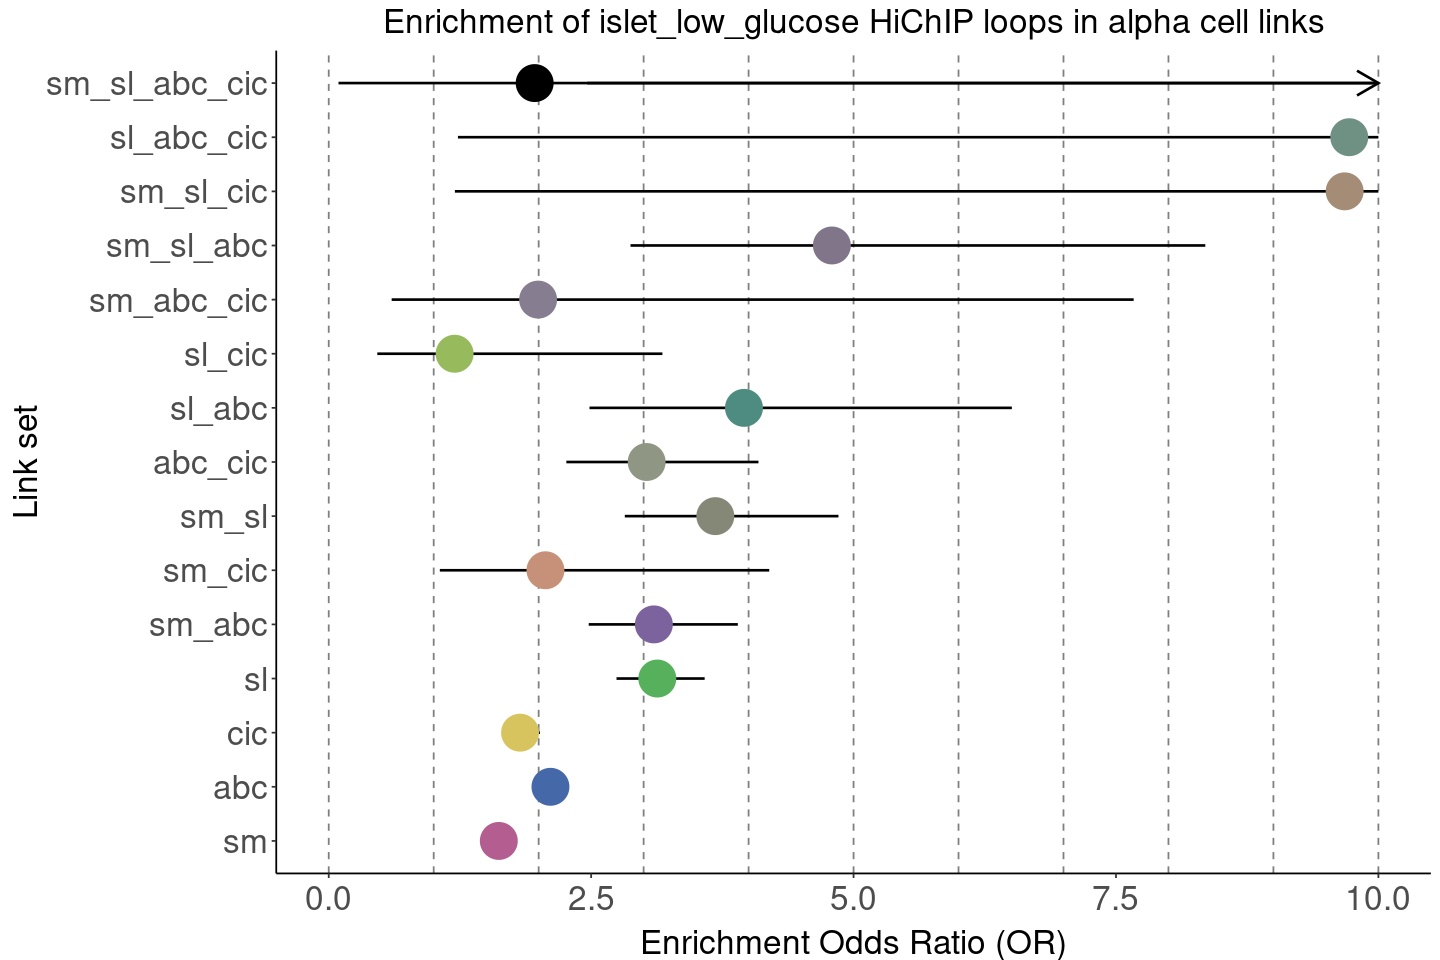

[1] "sl_abc_cic"


Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."
Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


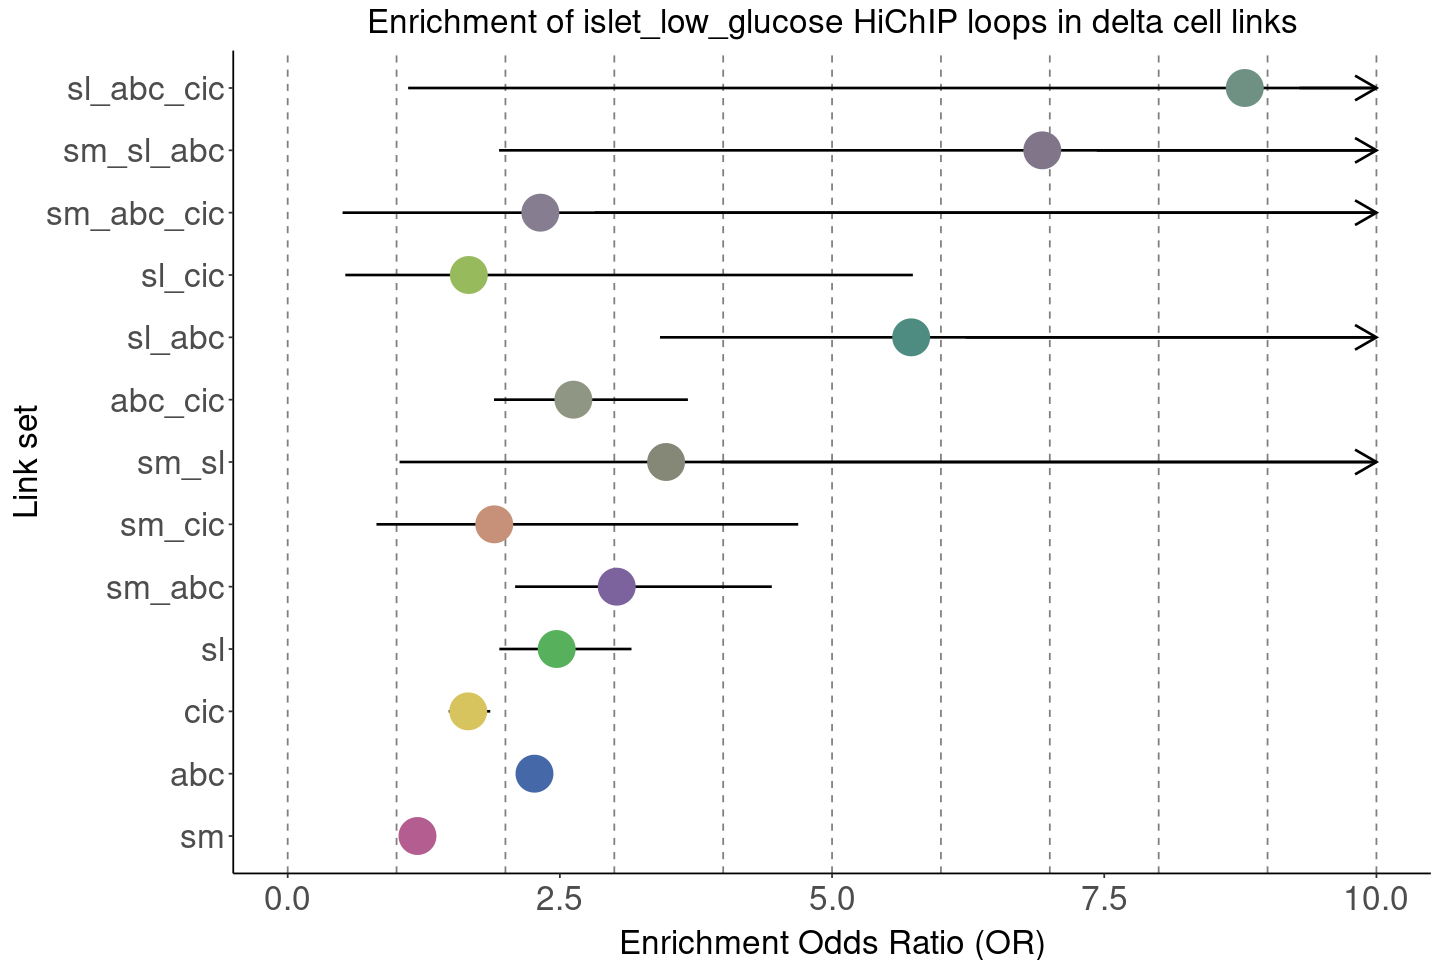

Warning message:
"Removed 11 rows containing missing values (`geom_segment()`)."


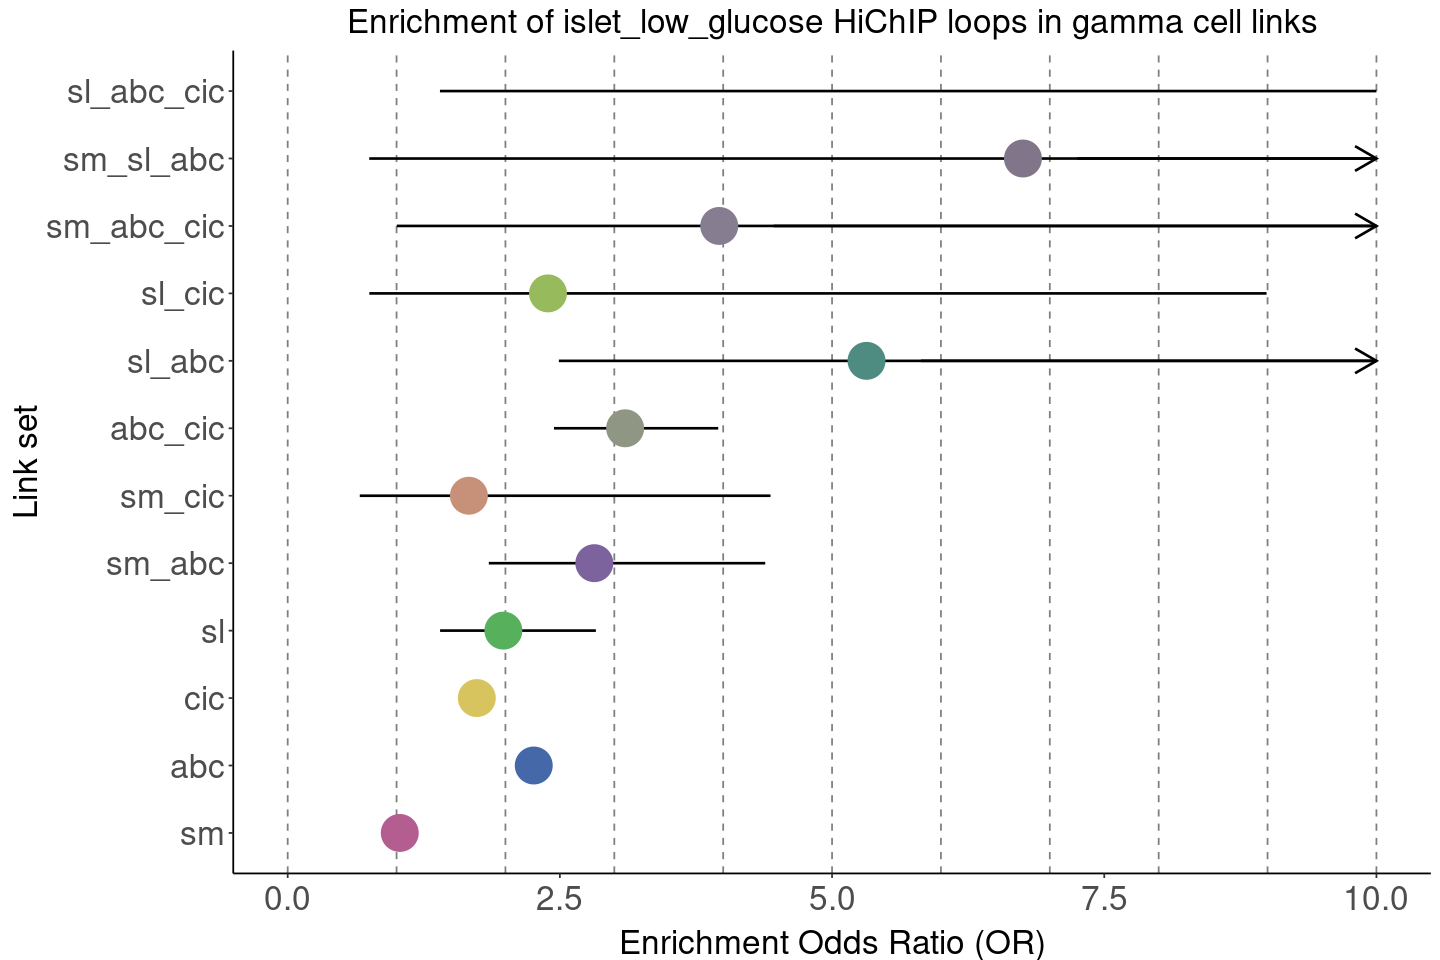

Warning message:
"Removed 9 rows containing missing values (`geom_segment()`)."


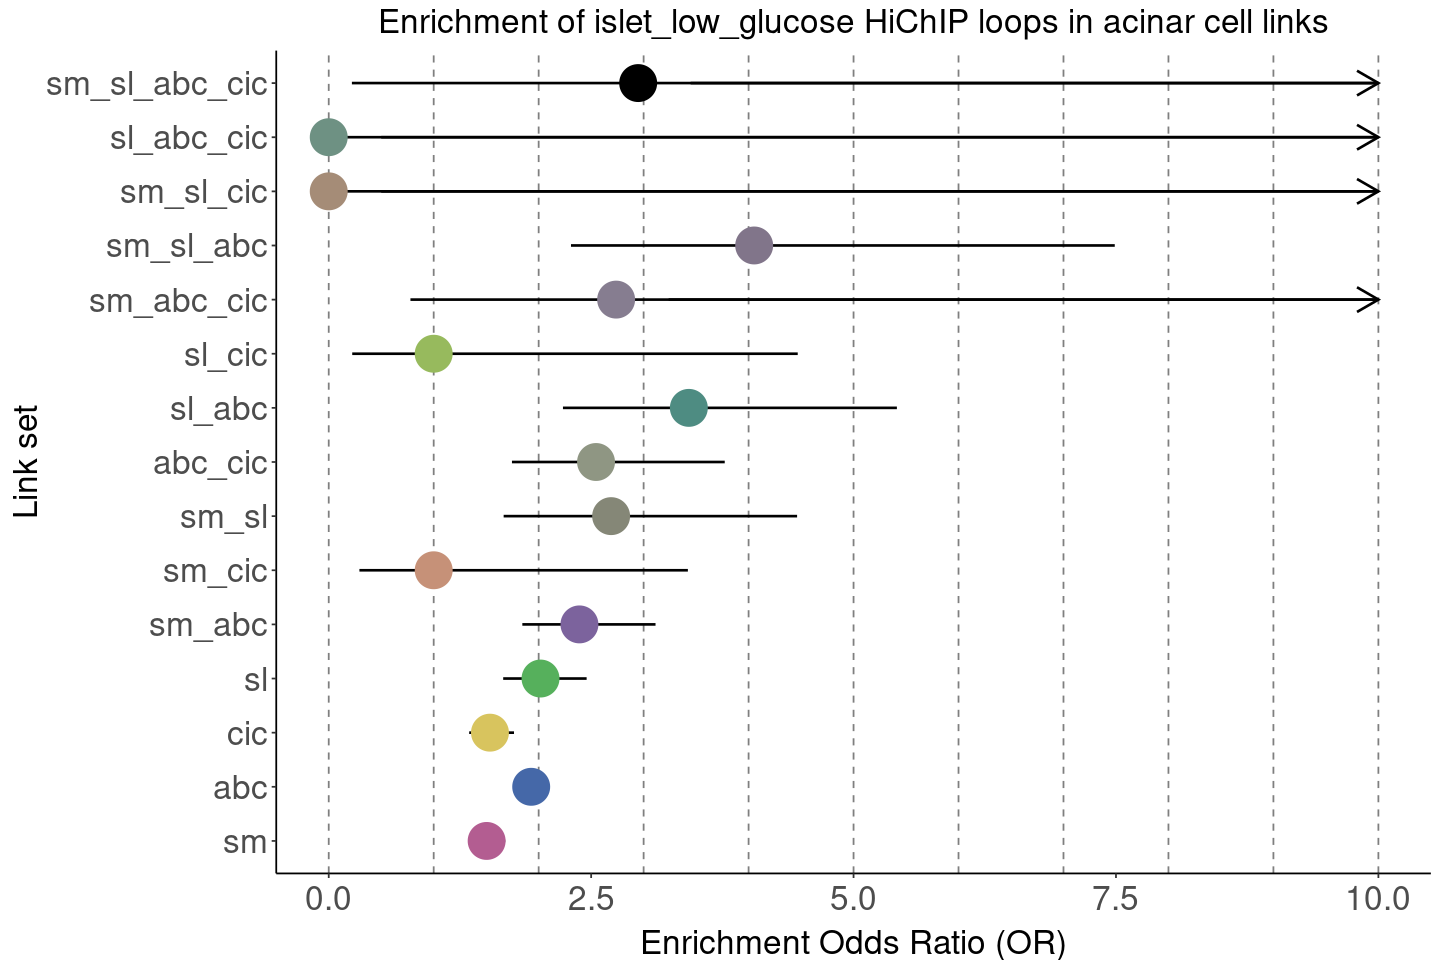

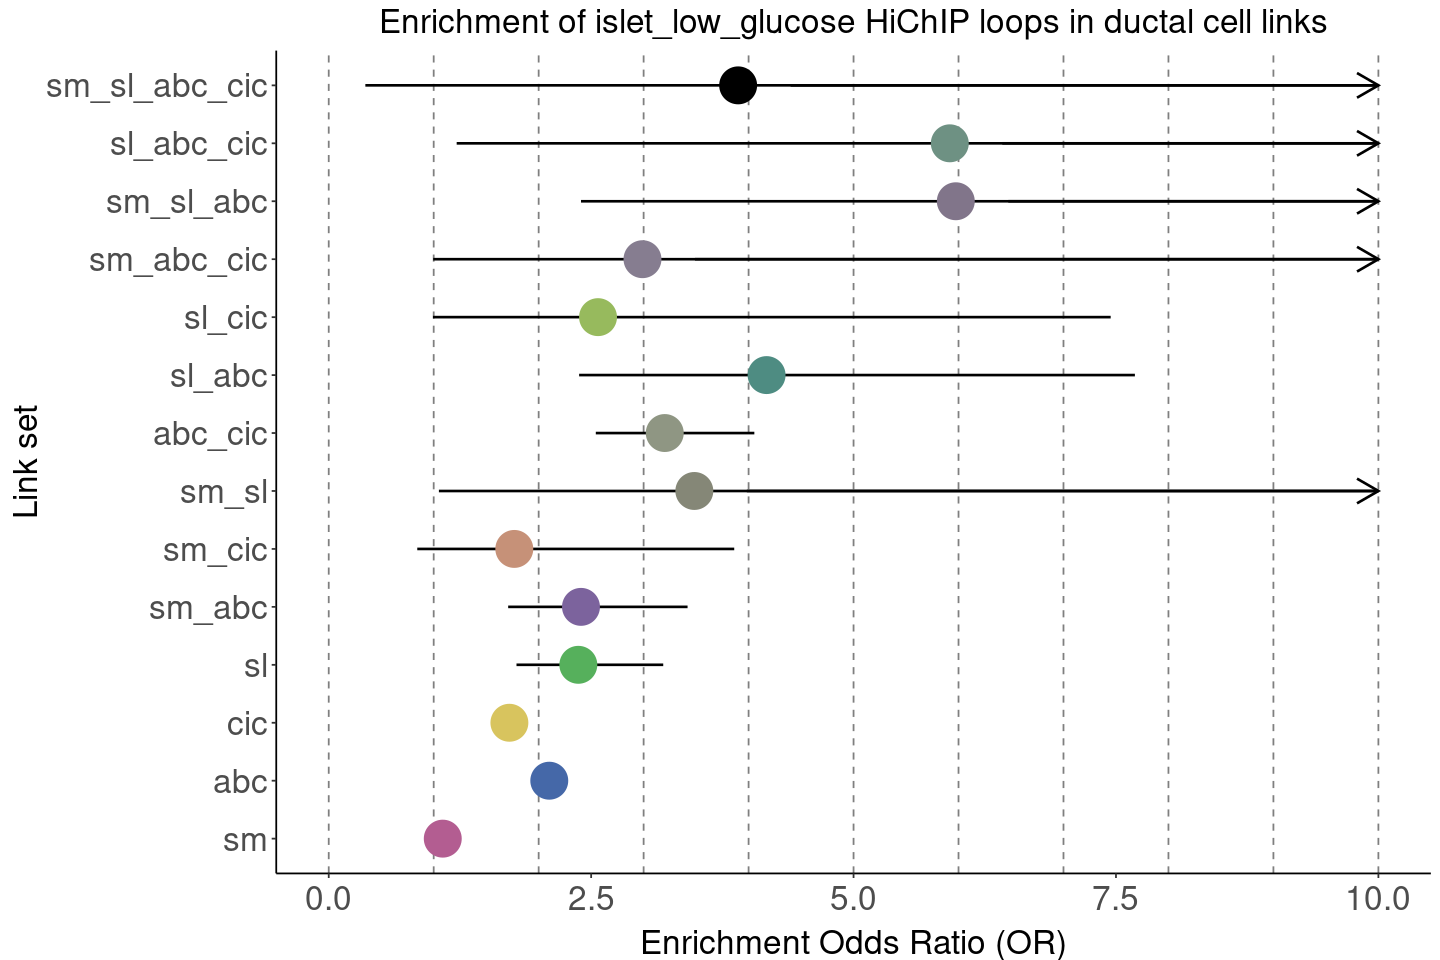

In [30]:
prefix <- prefixes[3]
for(celltype in celltypes){
    fp <- file.path(outdir, 'method_sets_enrichment', sprintf('%s_%s_HiChIP_overlap.link_methods_sets.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 10, link_sets, overlap_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links',prefix, celltype))
}

## Make plots for the distance bin results

In [31]:
num <- length(distance_bins)
method_colors <- c(rep(link_colors[['sm']],num), rep(link_colors[['sl']],num), rep(link_colors[['abc']],num), rep(link_colors[['cic']], num))
names(method_colors) <- paste(rep(link_methods, each=length(distance_bins)), distance_bins, sep='_')
method_colors

sm_100000-250000   sm_50000-100000    sm_10000-50000        sm_0-10000 
        "#B35D91"         "#B35D91"         "#B35D91"         "#B35D91" 
 sl_100000-250000   sl_50000-100000    sl_10000-50000        sl_0-10000 
        "#56B05C"         "#56B05C"         "#56B05C"         "#56B05C" 
abc_100000-250000  abc_50000-100000   abc_10000-50000       abc_0-10000 
        "#4568A8"         "#4568A8"         "#4568A8"         "#4568A8" 
cic_100000-250000  cic_50000-100000   cic_10000-50000       cic_0-10000 
        "#D8C45E"         "#D8C45E"         "#D8C45E"         "#D8C45E"

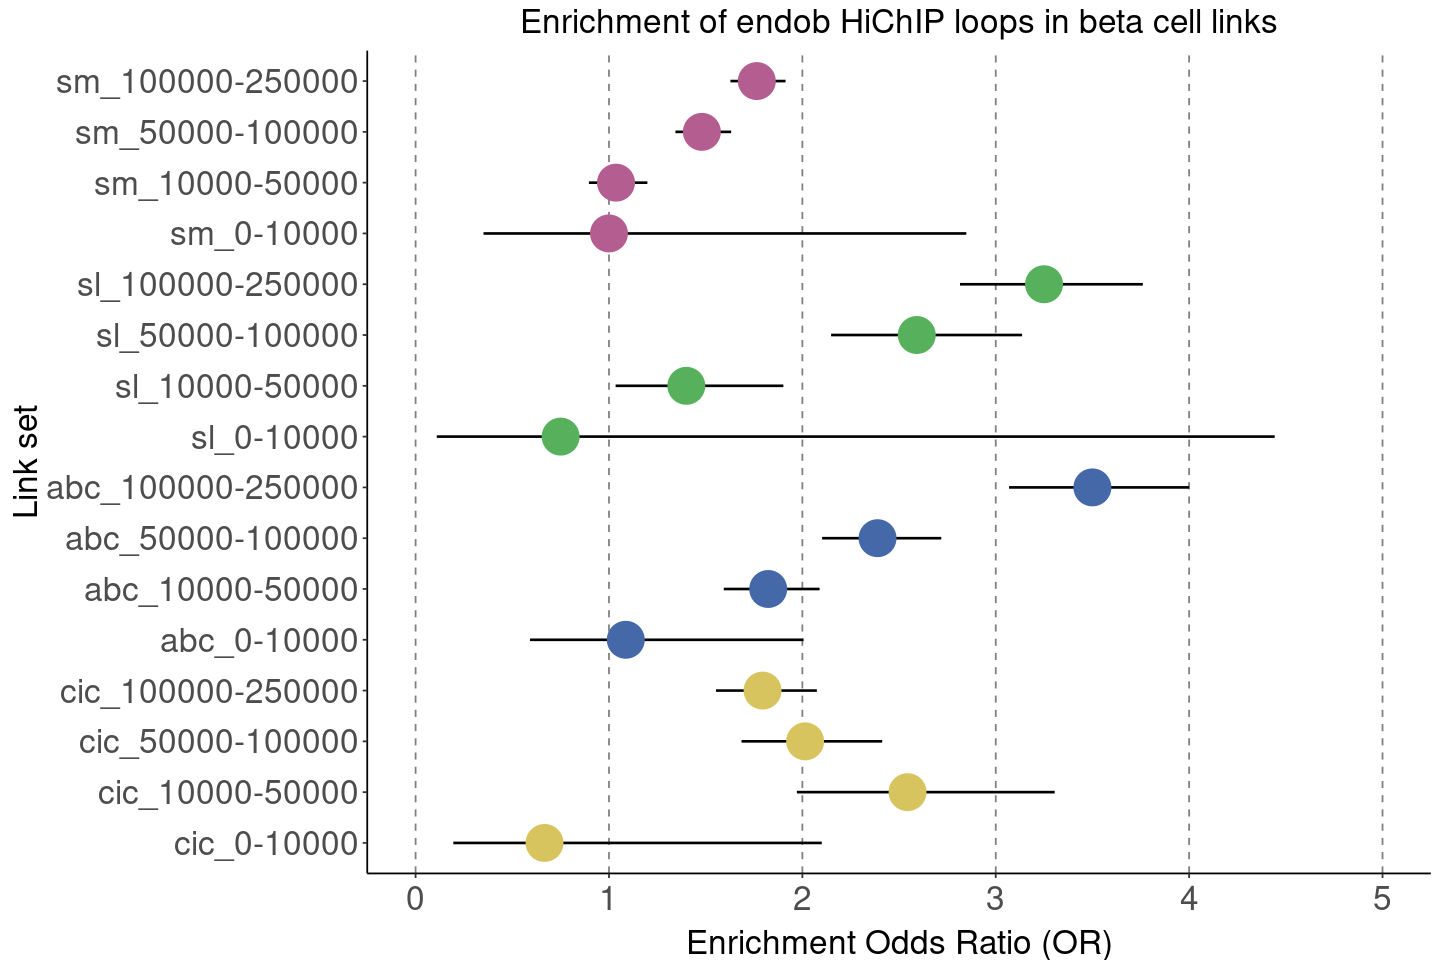

Warning message:
"Removed 13 rows containing missing values (`geom_segment()`)."


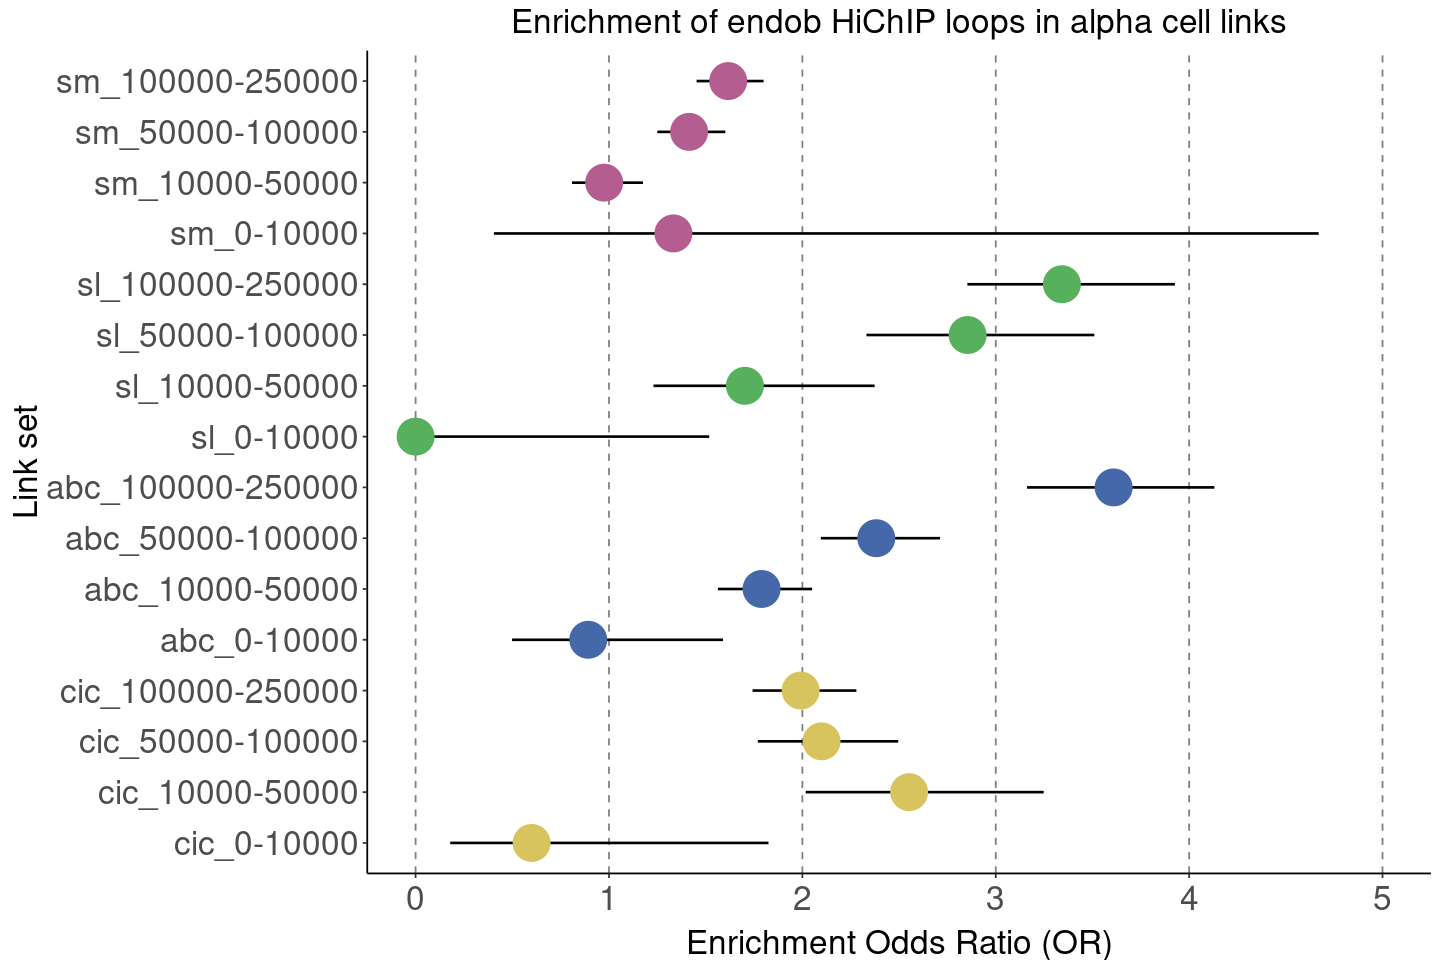

Warning message:
"Removed 11 rows containing missing values (`geom_segment()`)."


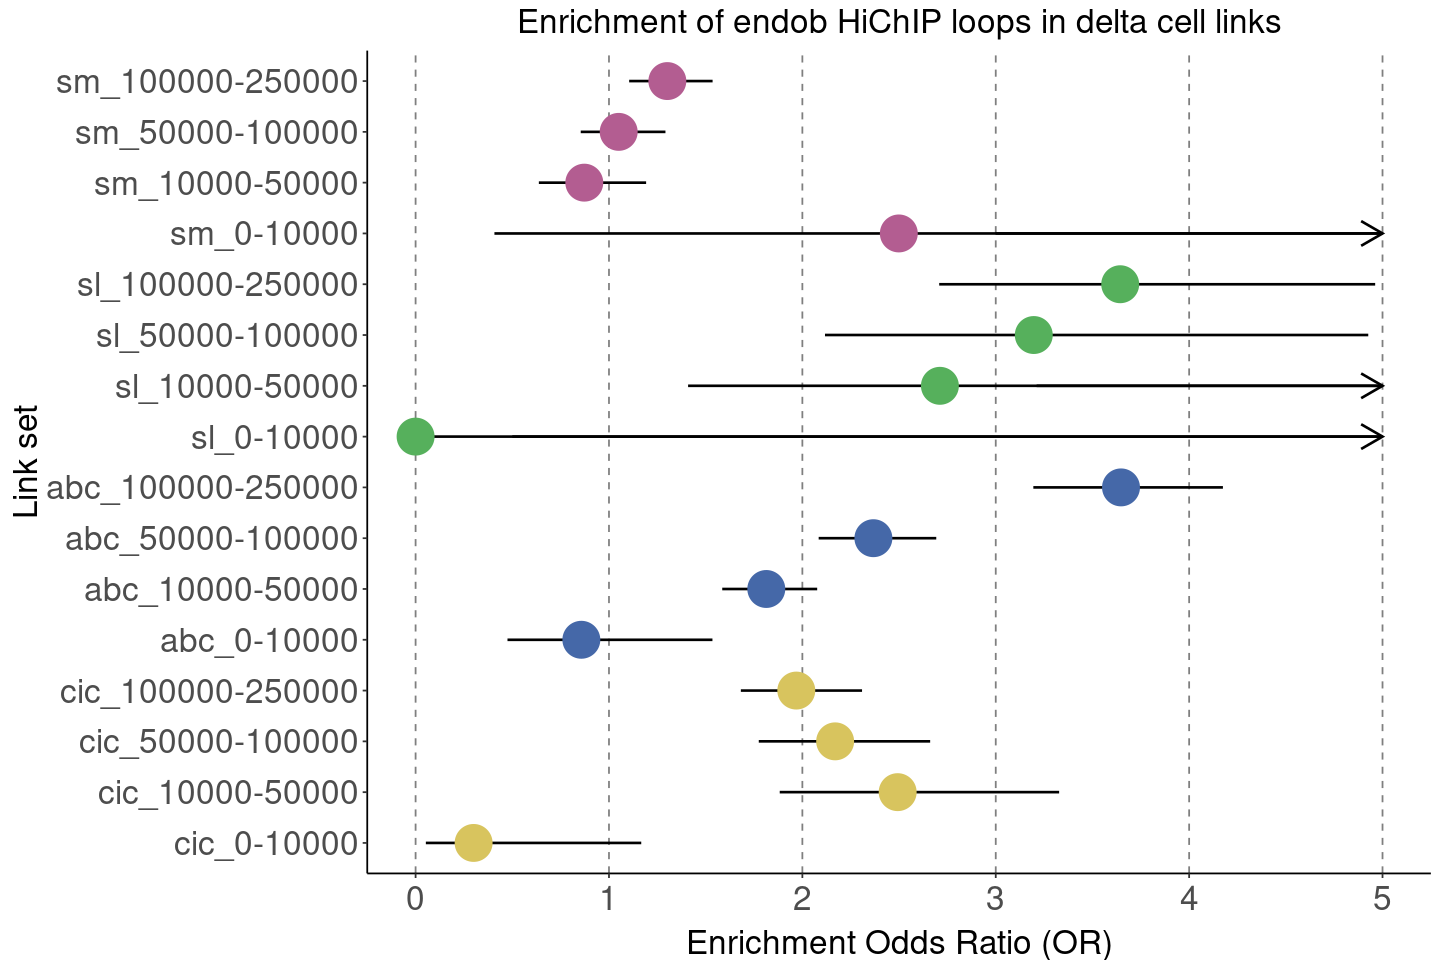

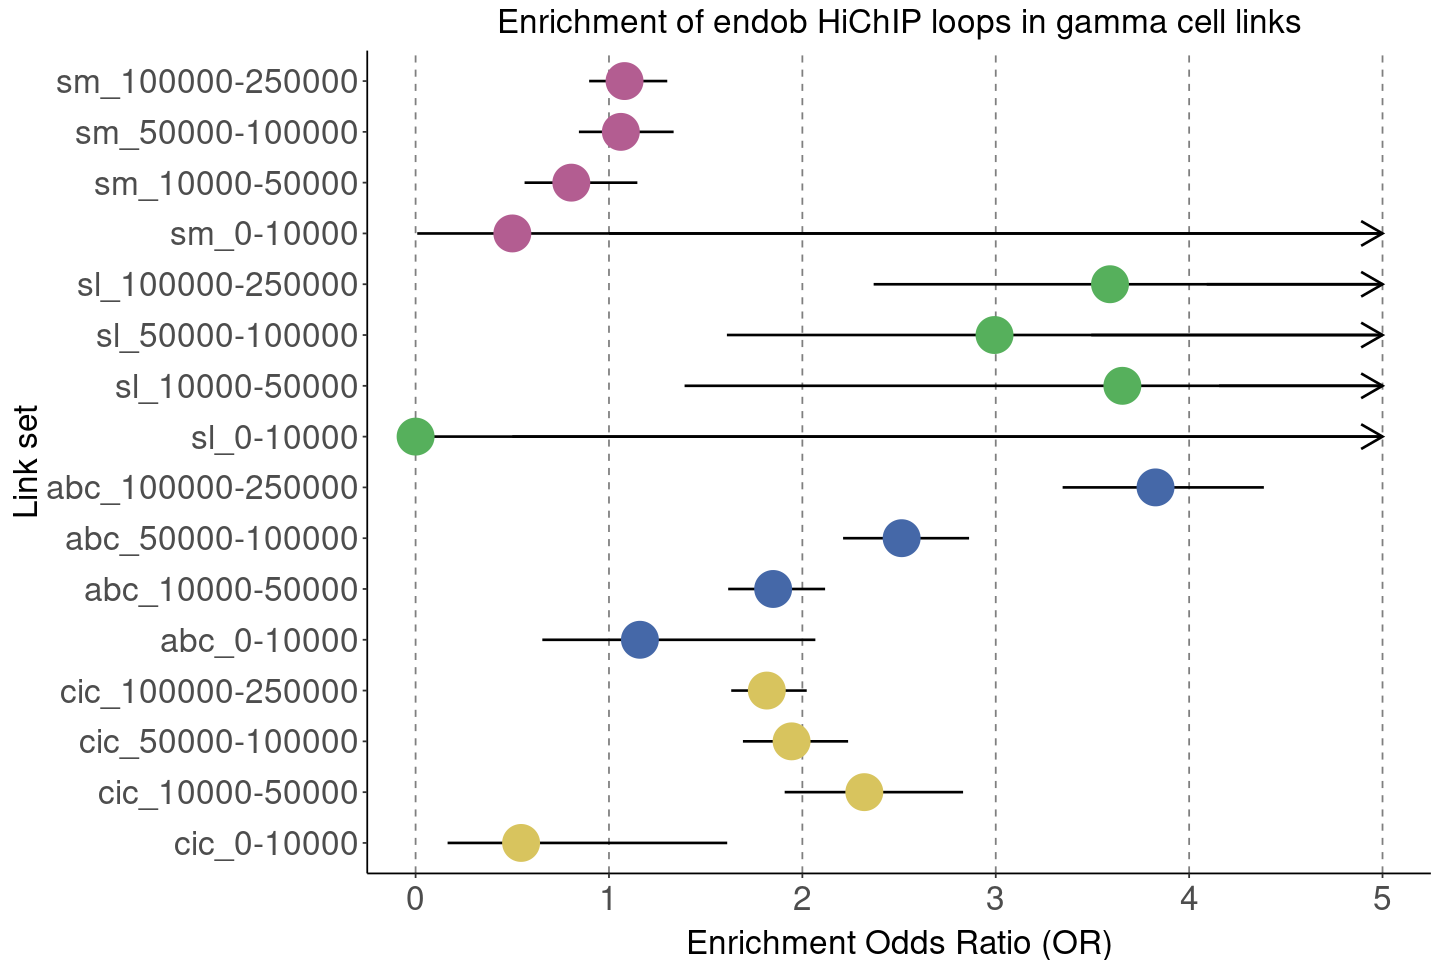

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


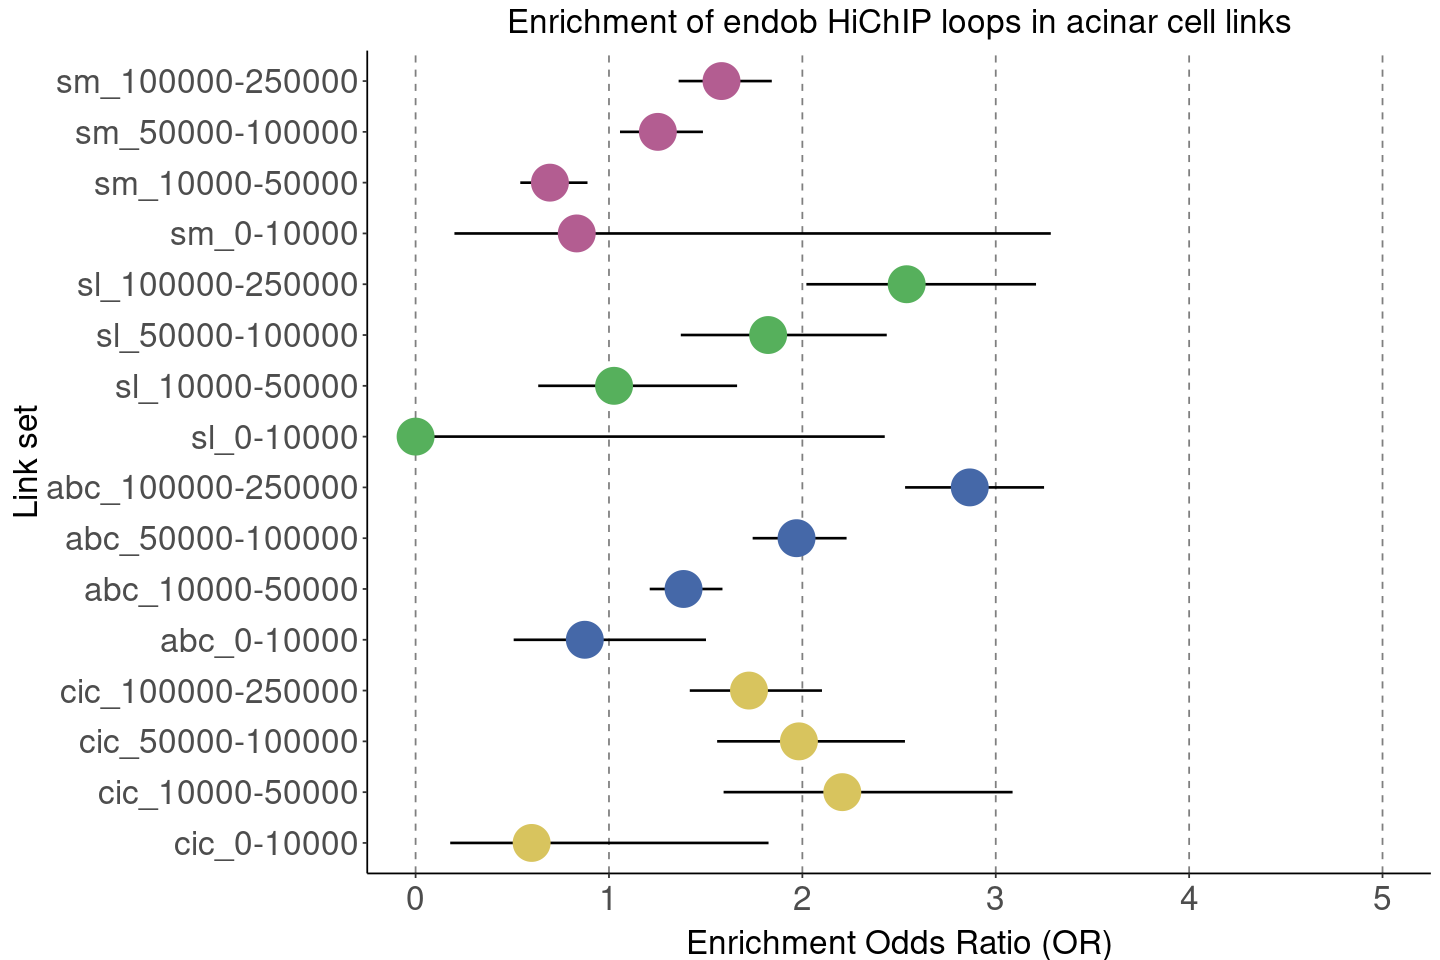

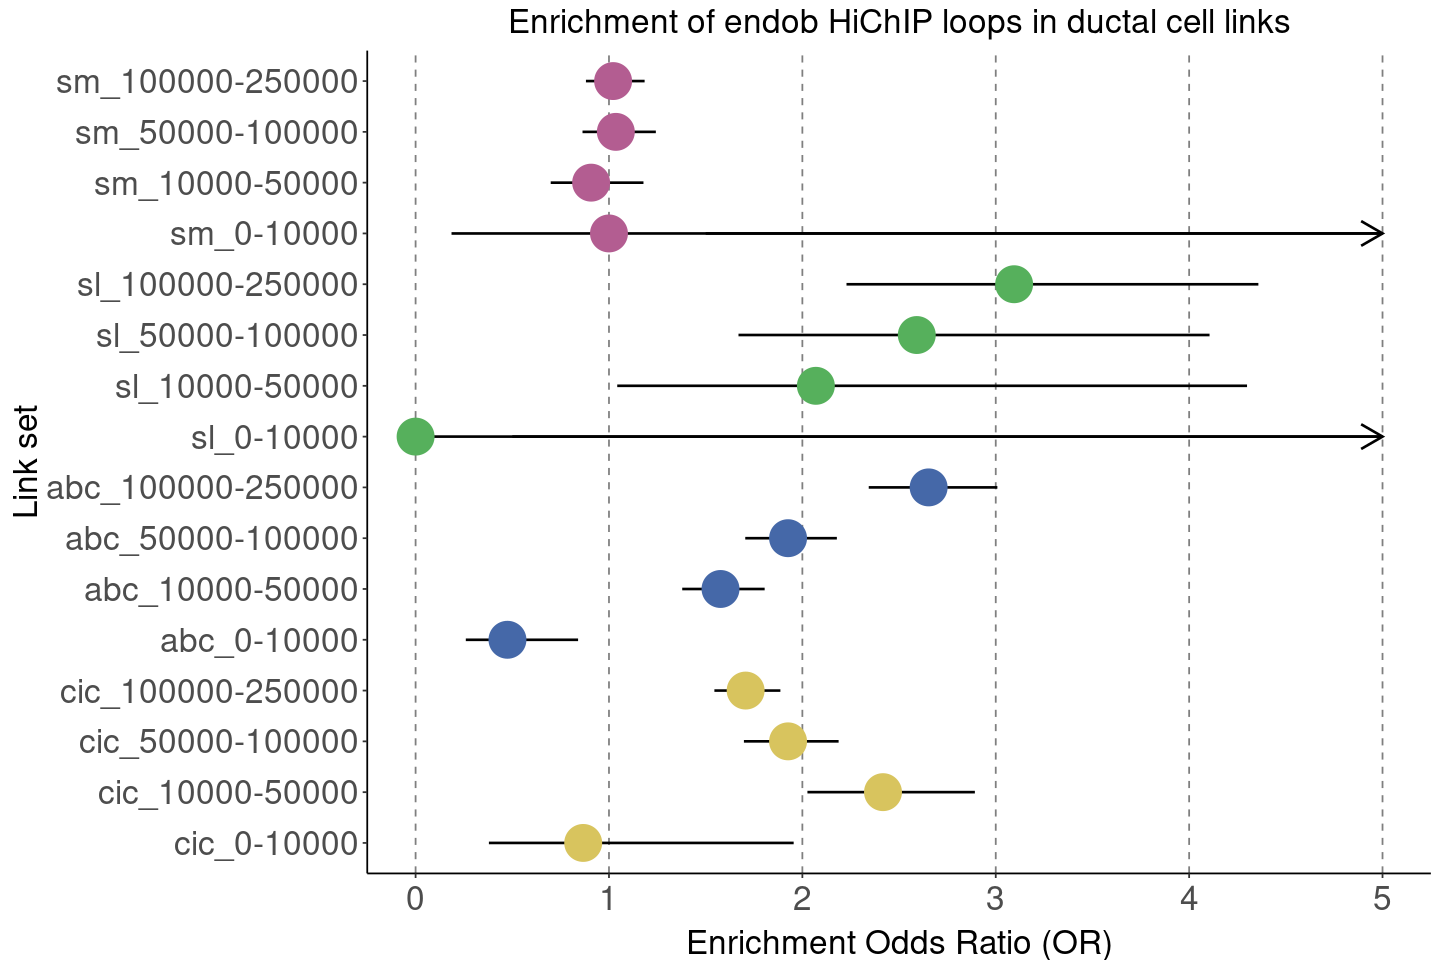

In [32]:
prefix <- prefixes[1]
for(celltype in celltypes){
    fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_%s_HiChIP_overlap.link_distance_bins.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 5, names(method_colors), method_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links', prefix, celltype))
}

Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."


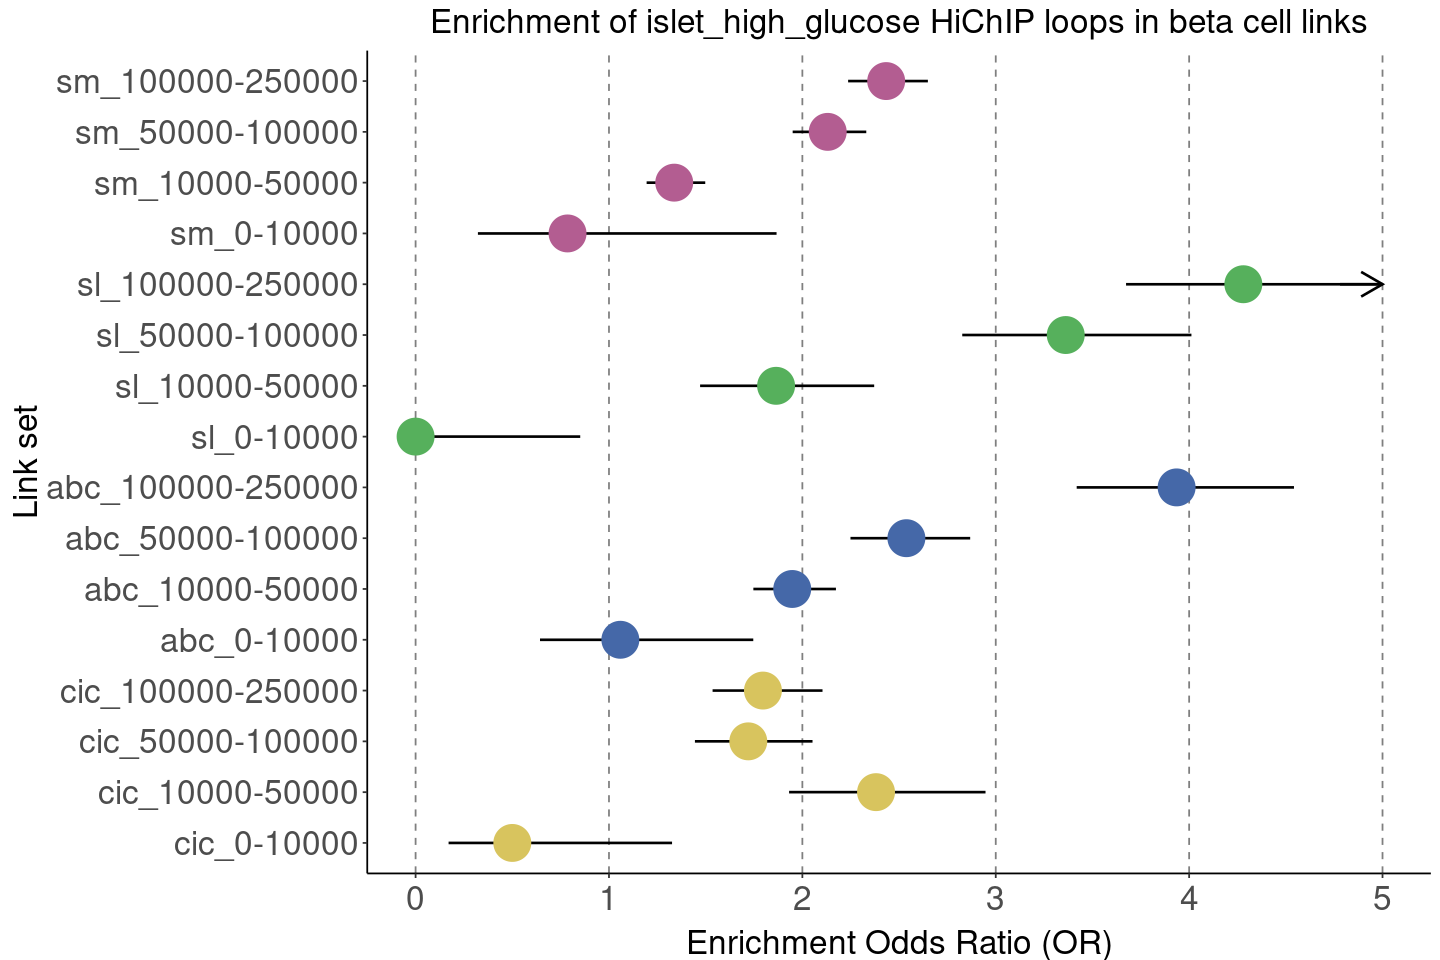

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


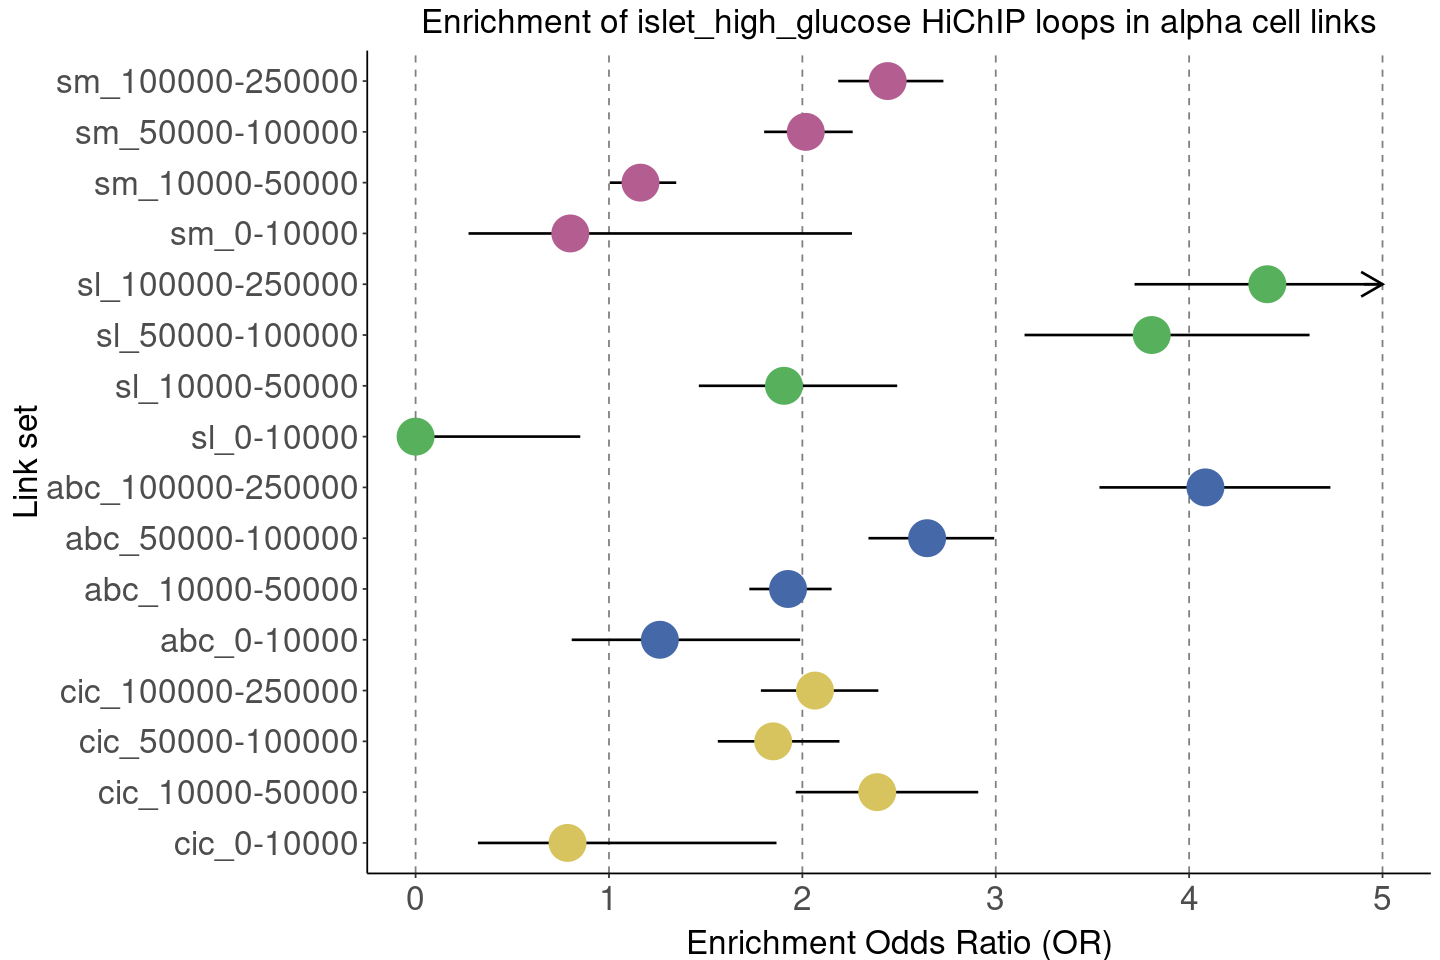

Warning message:
"Removed 11 rows containing missing values (`geom_segment()`)."


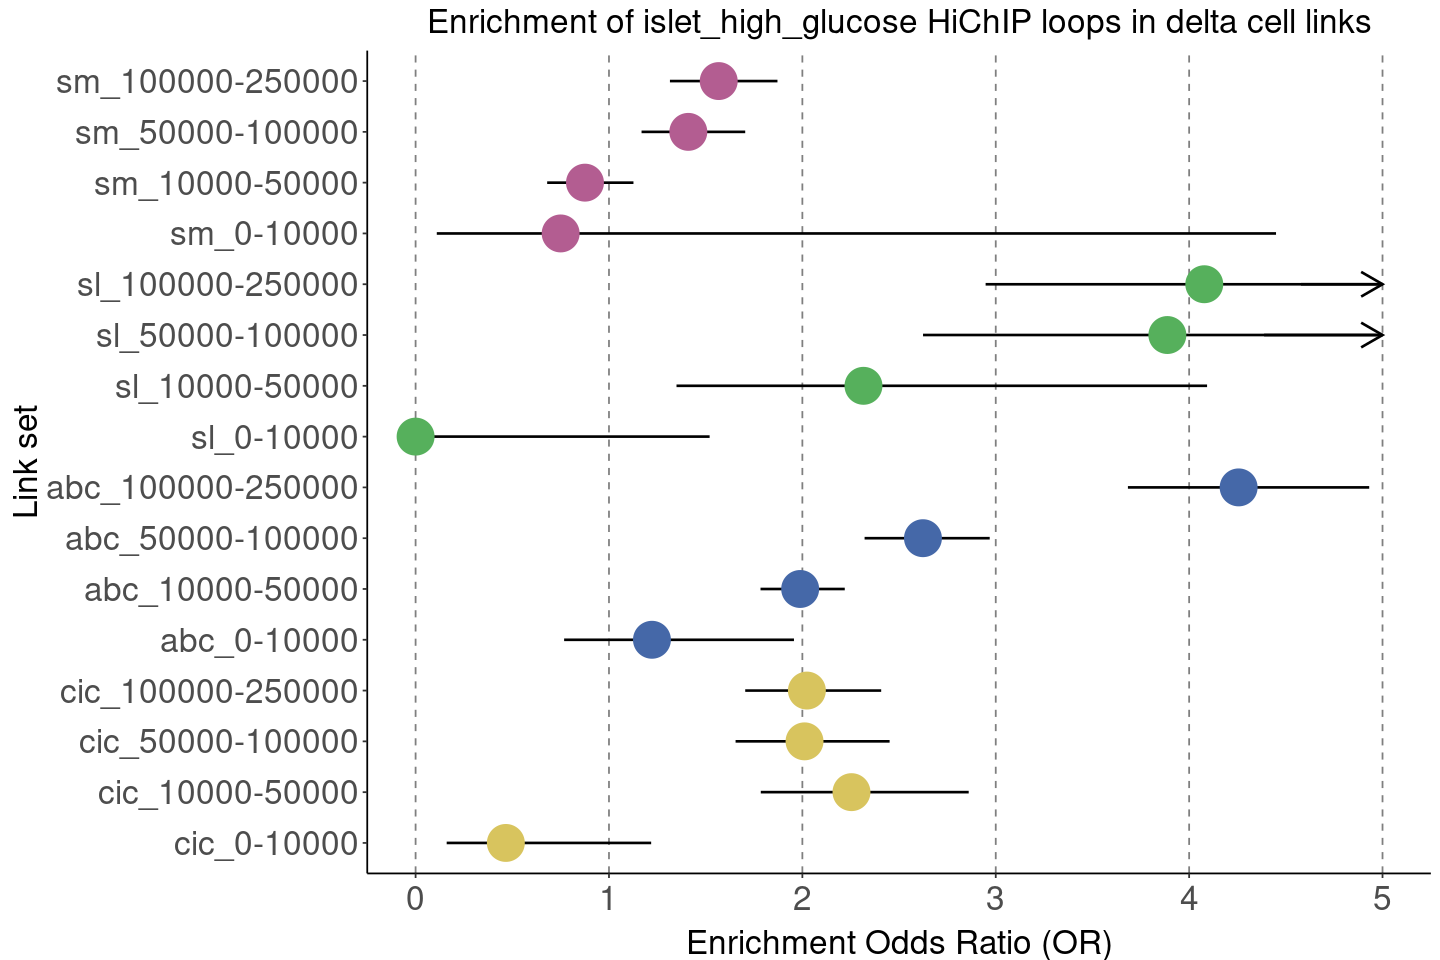

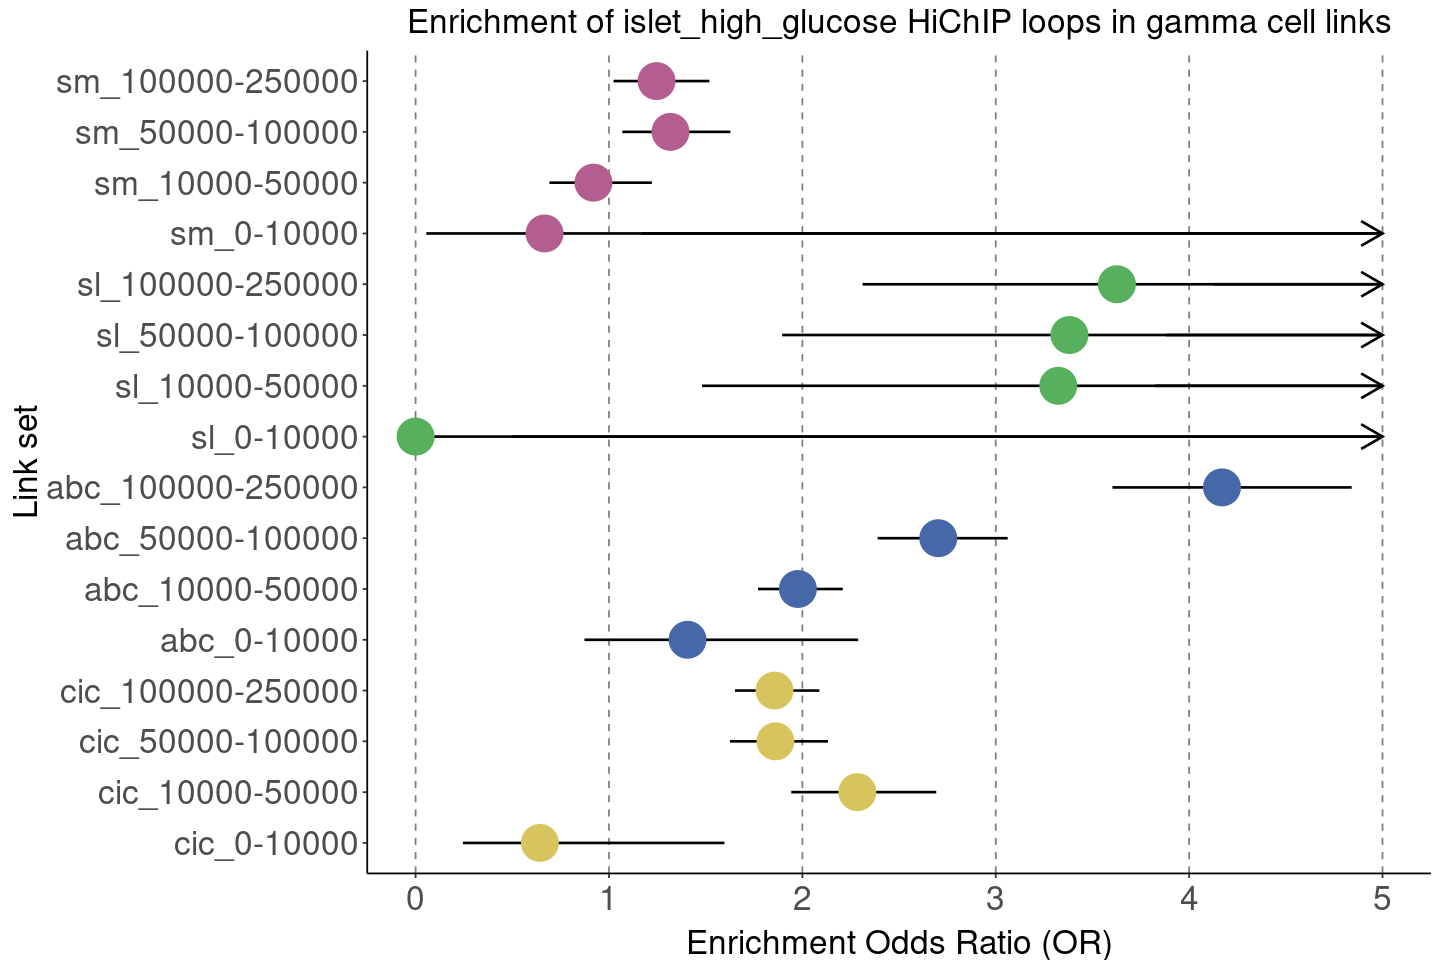

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


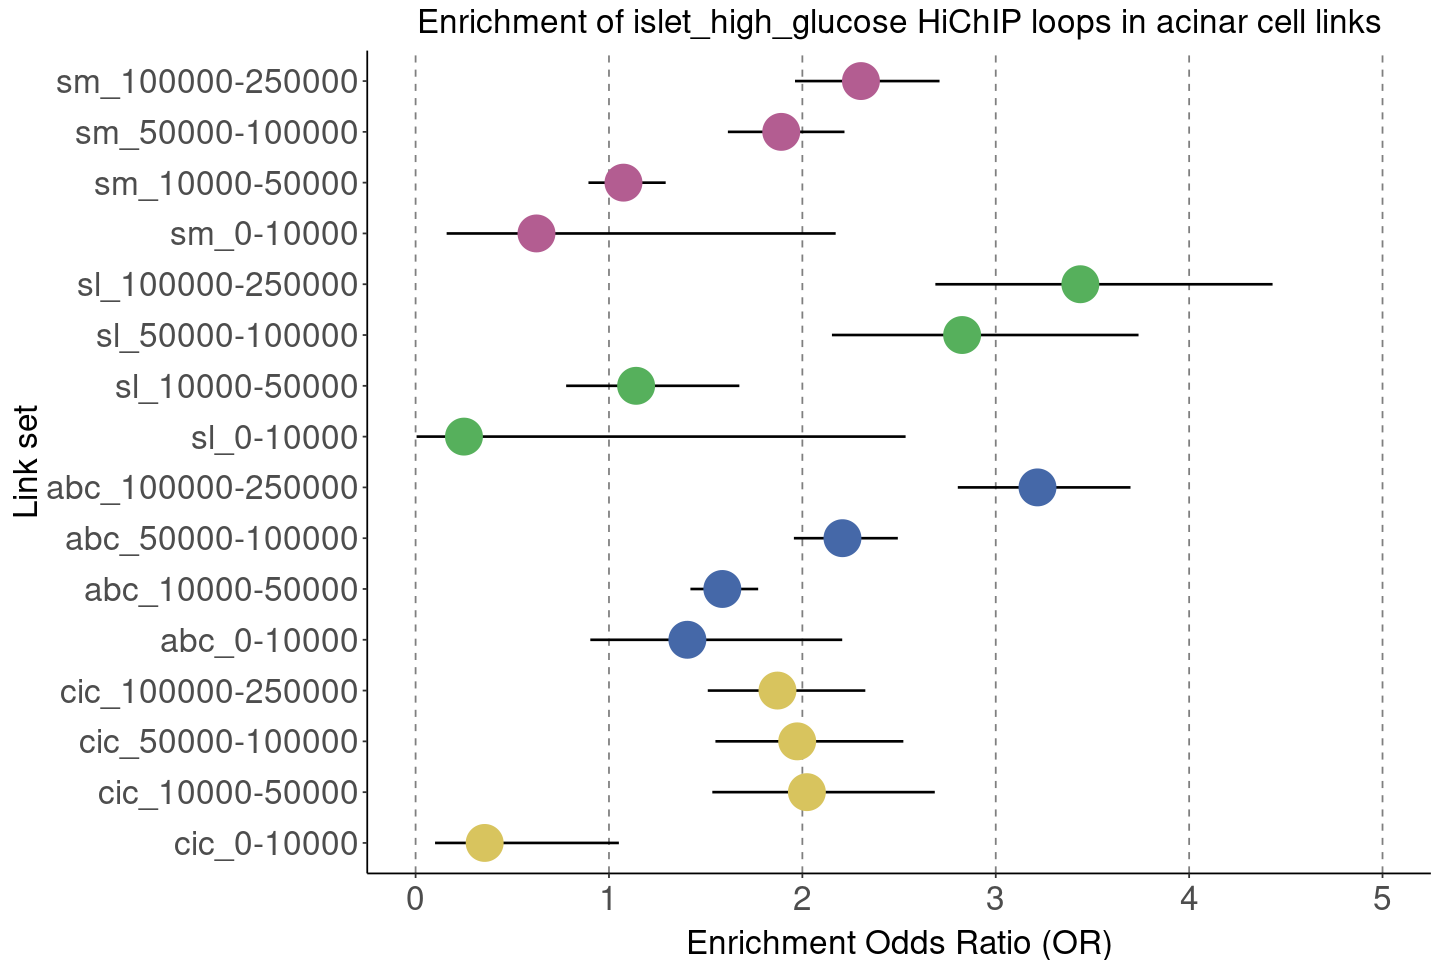

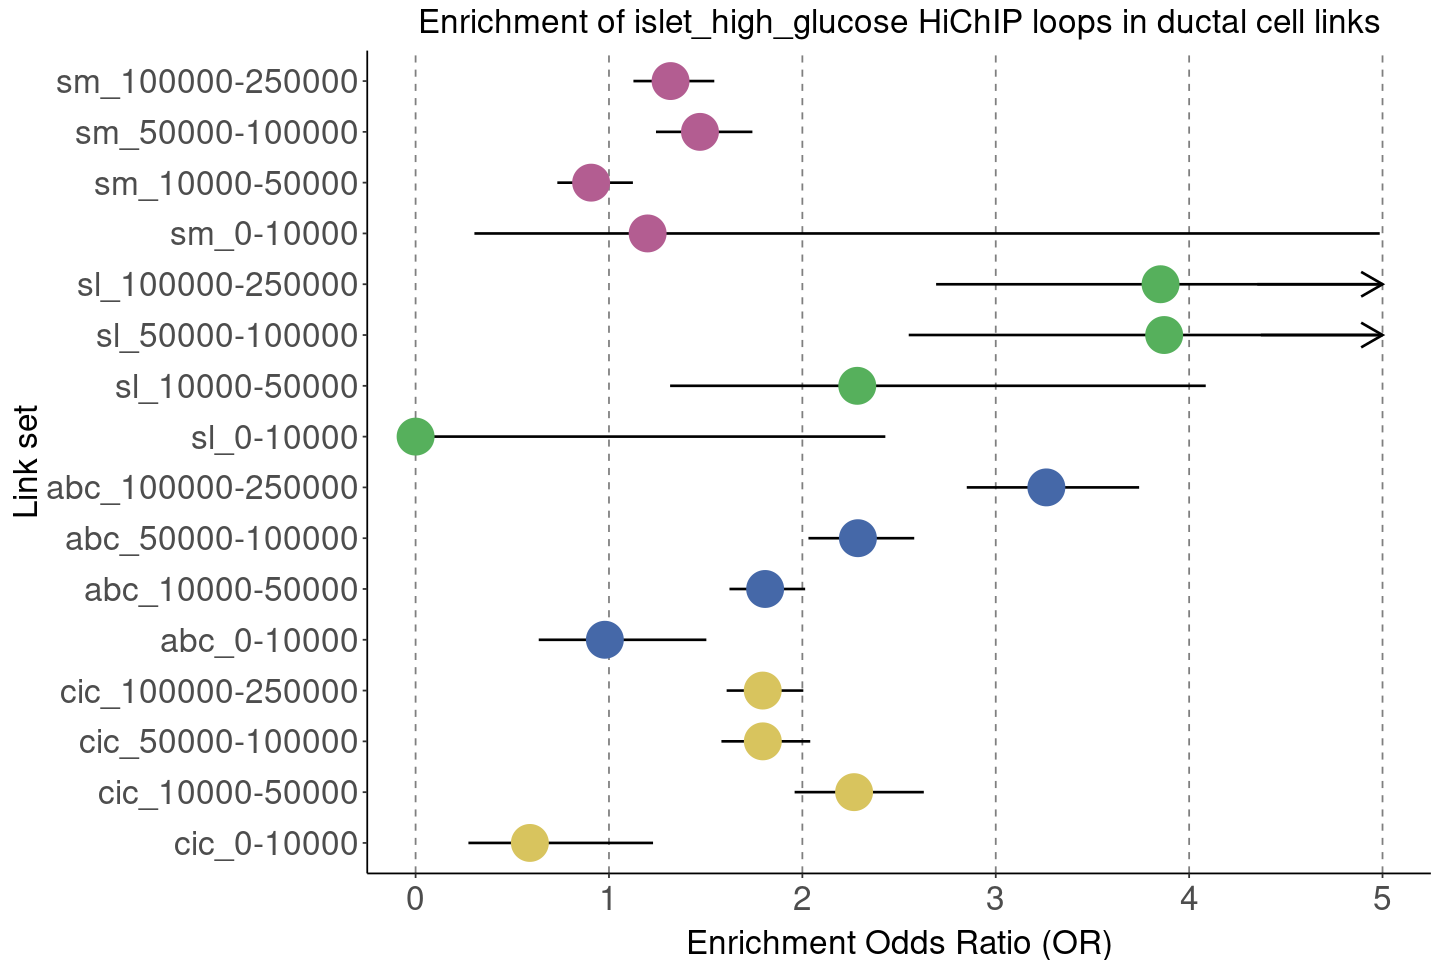

In [33]:
prefix <- prefixes[2]
for(celltype in celltypes){
    fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_%s_HiChIP_overlap.link_distance_bins.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 5, names(method_colors), method_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links', prefix, celltype))
}

Warning message:
"Removed 15 rows containing missing values (`geom_segment()`)."
Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


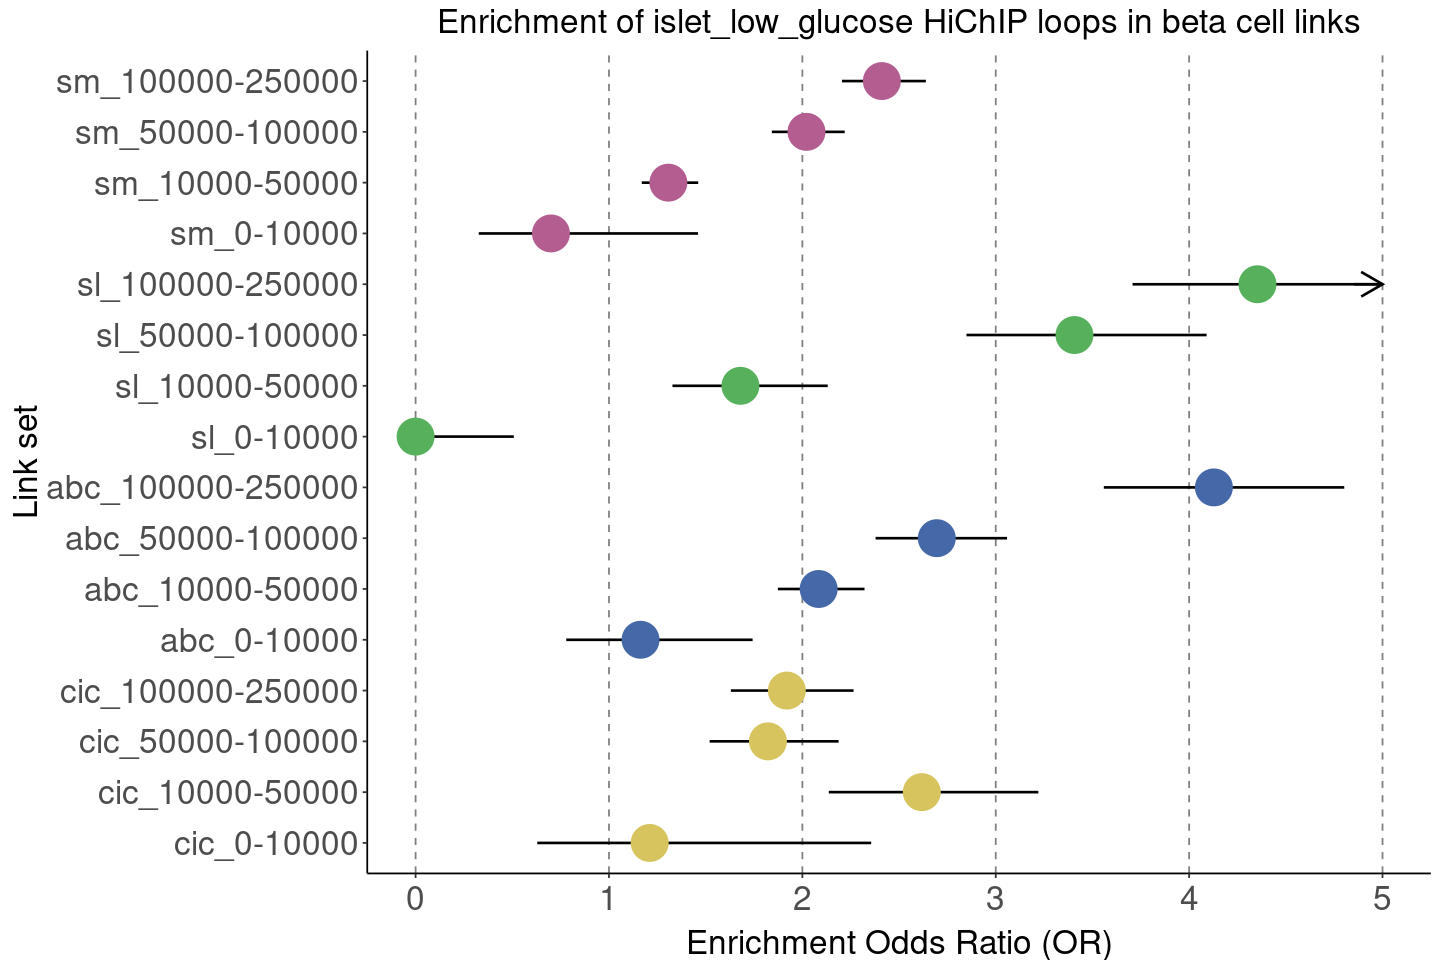

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


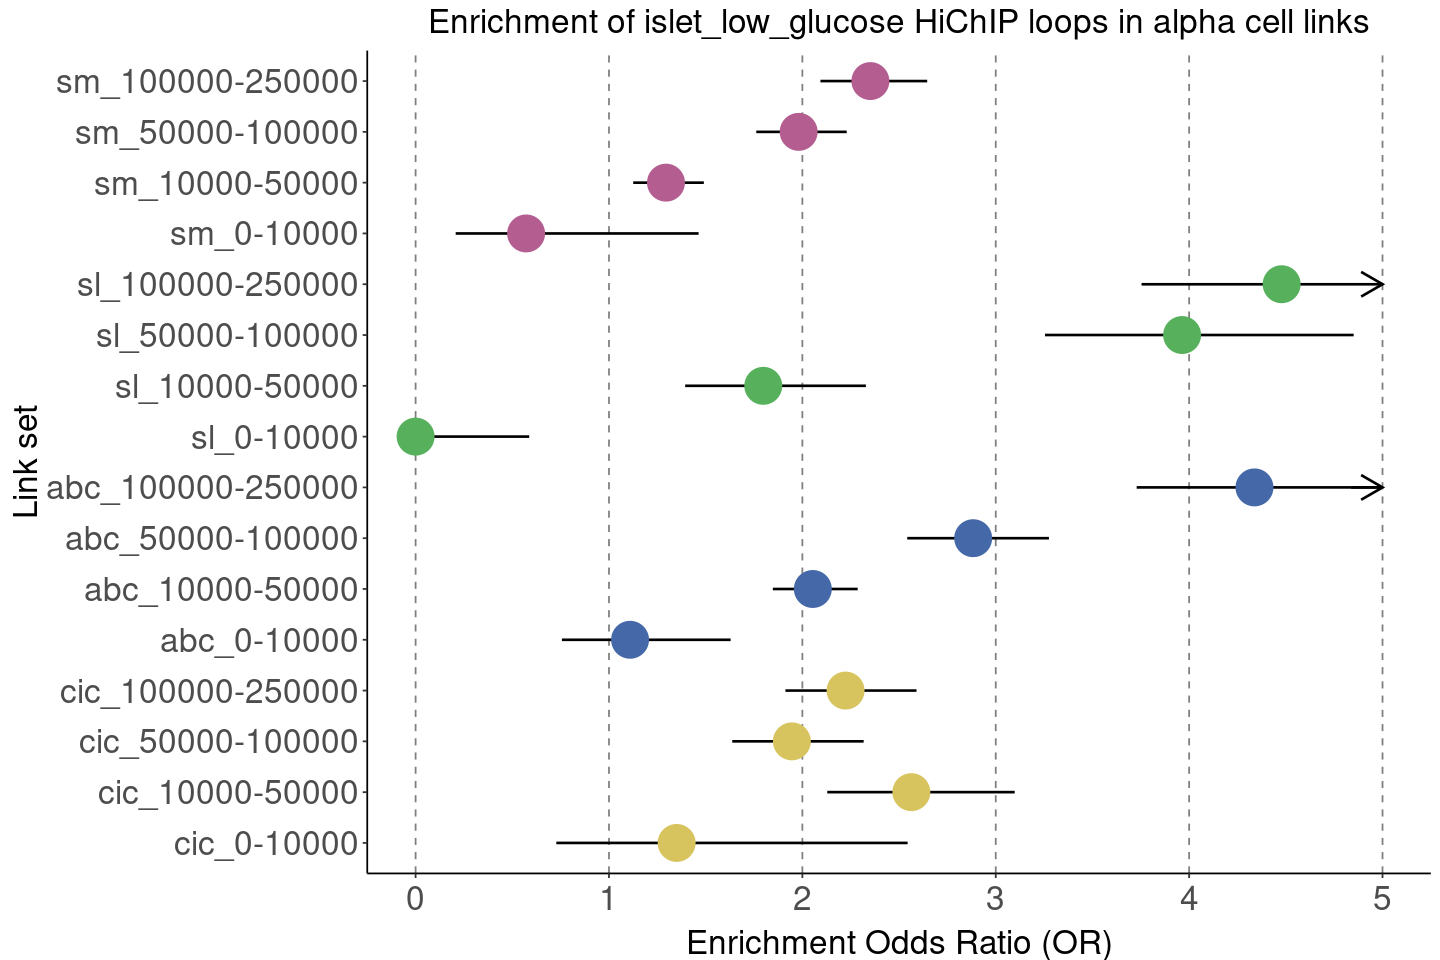

Warning message:
"Removed 12 rows containing missing values (`geom_segment()`)."


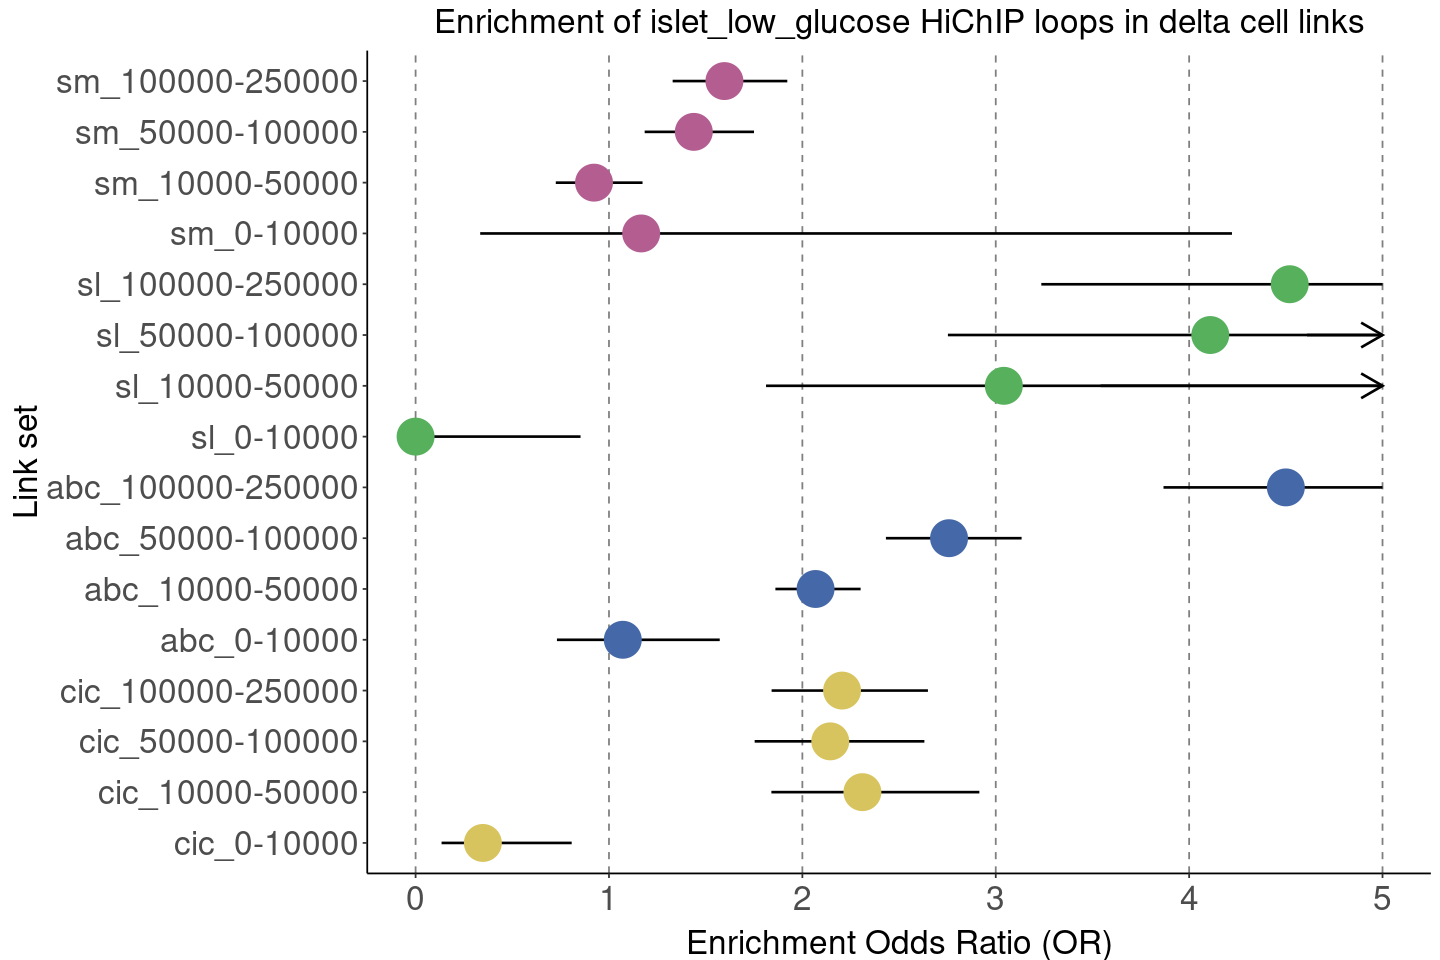

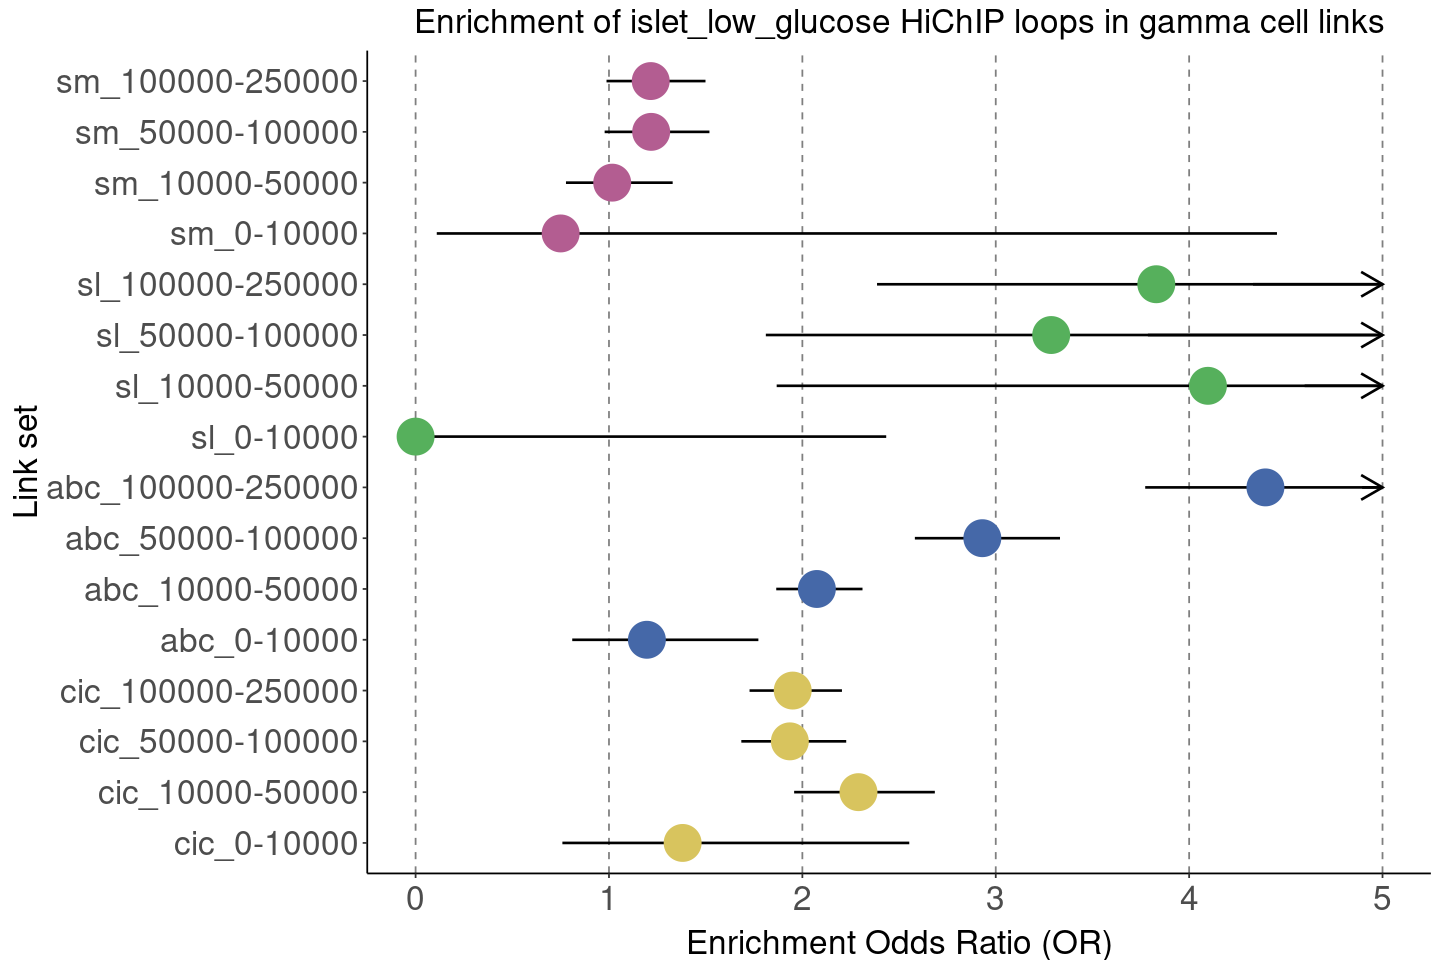

Warning message:
"Removed 14 rows containing missing values (`geom_segment()`)."


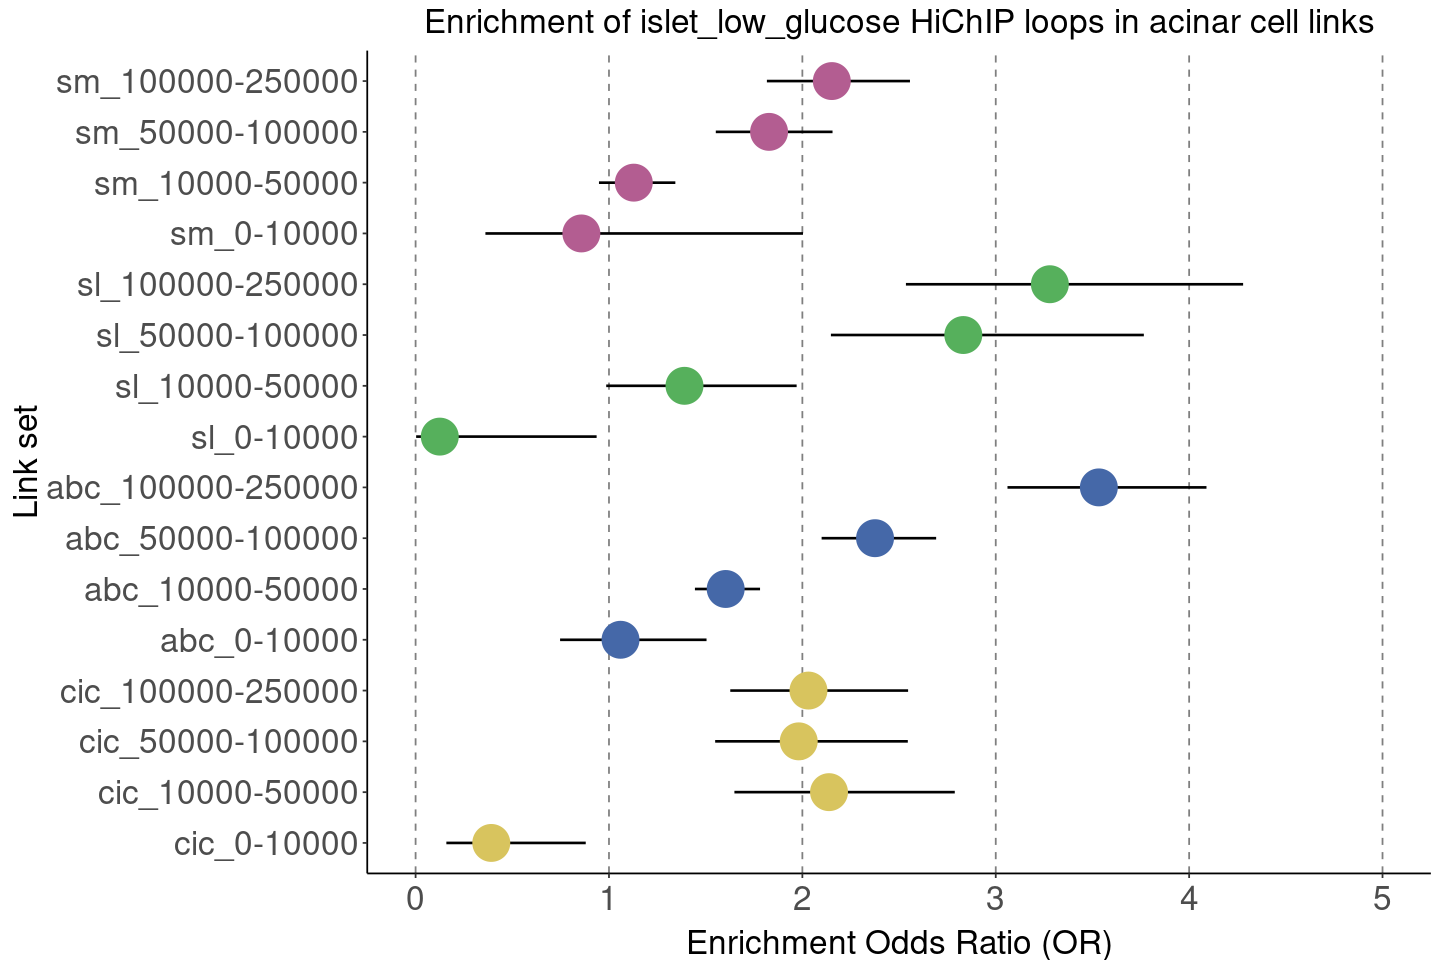

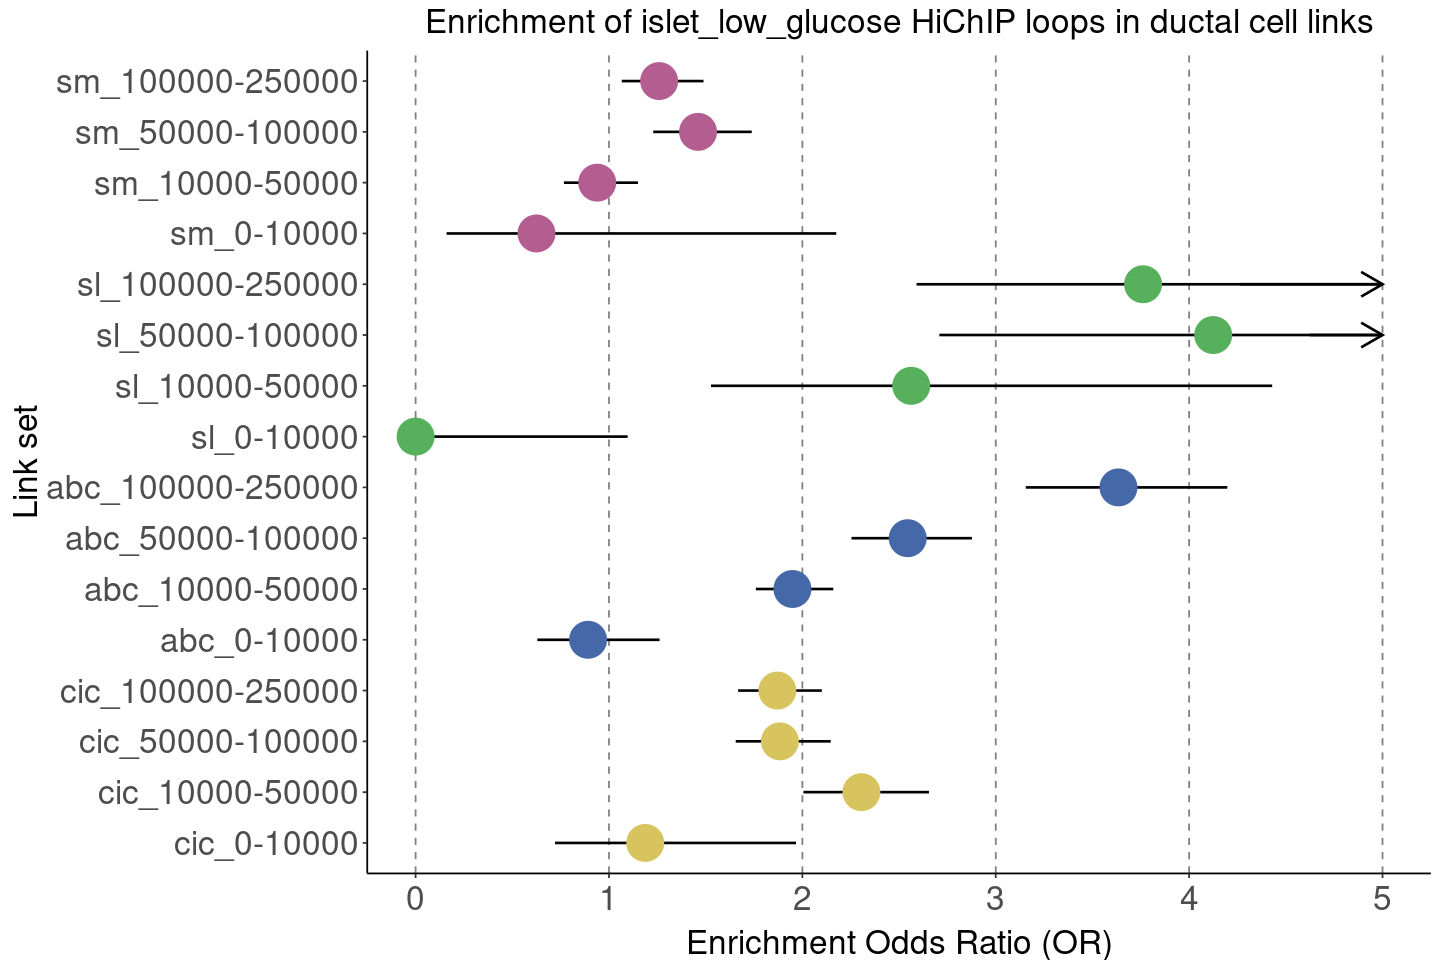

In [34]:
prefix <- prefixes[3]
for(celltype in celltypes){
    fp <- file.path(outdir, 'distance_bins_enrichment', sprintf('%s_%s_HiChIP_overlap.link_distance_bins.Fishers_enrichment.txt',celltype, prefix))
    plot_enrichment_comp_fin(fp, 5, names(method_colors), method_colors, sprintf('Enrichment of %s HiChIP loops in %s cell links', prefix, celltype))
}